## Carga de Dato y EDA BASICO

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [2]:
from google.colab import drive
import pandas as pd
import os

# Montar Google Drive
drive.mount('/content/drive')

# Sugerencia: Busca el archivo train.csv en tu Drive si no conoces la ruta exacta
# Por defecto, suele estar en '/content/drive/My Drive/train.csv' o subcarpetas
path_to_csv = '/content/drive/My Drive/ML_Notebooks/F1 Spit Stops/train.csv'

if os.path.exists(path_to_csv):
    df = pd.read_csv(path_to_csv)
    print("✅ Archivo cargado correctamente.")
    display(df.head())
else:
    print(f"❌ No se encontró el archivo en la ruta: {path_to_csv}")
    print("Por favor, ajusta la variable 'path_to_csv' con la ubicación correcta en tu Drive.")

Mounted at /content/drive
✅ Archivo cargado correctamente.


,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
0,0,D109,HARD,Canadian Grand Prix,2022,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,5.0,1.0
1,1,D086,HARD,Dutch Grand Prix,2025,1,27,2,7.0,4,75.095,-32.617,-223.207,0.346154,-3.0,0.0
2,2,ZON,HARD,Austrian Grand Prix,2022,0,59,3,22.0,13,70.945,-7.540,-100.529,0.819444,3.0,1.0
3,3,SPE,MEDIUM,Pre-Season Testing,2023,0,2,1,2.0,7,94.361,-7.324,-7.324,0.076923,0.0,0.0
4,4,D019,HARD,Azerbaijan Grand Prix,2022,1,26,3,6.0,2,107.878,8.965,-14.139,0.361111,3.0,0.0


In [3]:
print('--- Información del DataFrame ---')
display(df.info())

print('\n--- Resumen Estadístico ---')
display(df.describe())

--- Información del DataFrame ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 439140 entries, 0 to 439139
Data columns (total 16 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   id                      439140 non-null  int64  
 1   Driver                  439140 non-null  object 
 2   Compound                439140 non-null  object 
 3   Race                    439140 non-null  object 
 4   Year                    439140 non-null  int64  
 5   PitStop                 439140 non-null  int64  
 6   LapNumber               439140 non-null  int64  
 7   Stint                   439140 non-null  int64  
 8   TyreLife                439140 non-null  float64
 9   Position                439140 non-null  int64  
 10  LapTime (s)             439140 non-null  float64
 11  LapTime_Delta           439140 non-null  float64
 12  Cumulative_Degradation  439140 non-null  float64
 13  RaceProgress            439140 non-null 

None


--- Resumen Estadístico ---


,id,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
count,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000
mean,219569.500000,2023.523544,0.136118,23.105909,1.789113,14.158231,9.630339,90.948735,-3.770040,-25.721759,0.337661,0.101542,0.198982
std,126768.942943,1.024930,0.342915,16.958261,0.950194,9.801338,5.278770,19.772769,43.945759,54.766573,0.253277,4.006765,0.399235
min,0.000000,2022.000000,0.000000,1.000000,1.000000,1.000000,1.000000,67.694000,-2403.895000,-274.564000,0.012821,-18.000000,0.000000
25%,109784.750000,2023.000000,0.000000,9.000000,1.000000,6.000000,5.000000,82.621000,-8.884000,-46.566250,0.129870,-1.000000,0.000000
50%,219569.500000,2024.000000,0.000000,19.000000,2.000000,12.000000,10.000000,90.521000,-0.295000,-20.994000,0.269231,0.000000,0.000000
75%,329354.250000,2024.000000,0.000000,36.000000,2.000000,20.000000,14.000000,98.471000,0.115000,-6.199000,0.513158,2.000000,0.000000
max,439139.000000,2025.000000,1.000000,78.000000,8.000000,77.000000,20.000000,2507.607000,2423.932000,2412.026000,1.000000,18.000000,1.000000


## Driver

Hay un total de 887 pilotos y en promedio cada uno cuenta con 495 carreras.

Número de valores únicos en Driver: 887


/tmp/ipykernel_945/3795869587.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_drivers.index, y=top_drivers.values, palette='viridis')


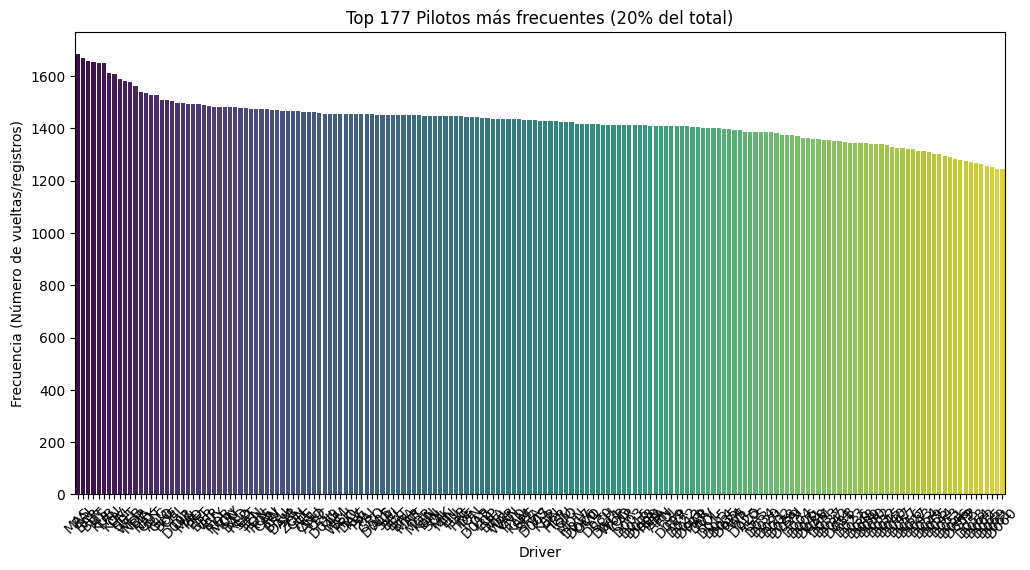

--- Tabla de Extremos (Top 5 y Bottom 5) ---


,Número de Carreras
Driver,
MAS,1682
RAI,1669
BAR,1656
BUT,1655
FIS,1651
D723,1
D677,1
D731,1
D716,1



El número promedio de carreras (registros) por piloto es: 495.08


In [4]:
# 1. Calcular valores únicos de Driver
unique_drivers = df['Driver'].nunique()
print(f'Número de valores únicos en Driver: {unique_drivers}')

# 2. Obtener frecuencias de todos los pilotos
driver_counts = df['Driver'].value_counts()

# 3. Calcular cuántos pilotos representan el 20% superior
top_20_percent_count = int(len(driver_counts) * 0.20)
top_drivers = driver_counts.head(top_20_percent_count)

# 4. Graficar
plt.figure(figsize=(12, 6))
sns.barplot(x=top_drivers.index, y=top_drivers.values, palette='viridis')
plt.title(f'Top {top_20_percent_count} Pilotos más frecuentes (20% del total)')
plt.xlabel('Driver')
plt.ylabel('Frecuencia (Número de vueltas/registros)')
plt.xticks(rotation=45)
plt.show()

# 1. Obtener los 5 con más y menos carreras
top_5 = driver_counts.head(5)
bottom_5 = driver_counts.tail(5)

# 2. Crear una tabla comparativa
summary_table = pd.concat([top_5, bottom_5]).to_frame(name='Número de Carreras')
summary_table.index.name = 'Driver'

print('--- Tabla de Extremos (Top 5 y Bottom 5) ---')
display(summary_table)

# 3. Calcular el promedio de carreras
average_races = driver_counts.mean()
print(f'\nEl número promedio de carreras (registros) por piloto es: {average_races:.2f}')

Hay un total de 887 pilotos unicos y los que mas carreras han tenido tienen 1600 carreras. El promedio de carreras por piloto es 496.

## Compound
El gráfico muestra claramente que el compuesto MEDIUM domina el conjunto de datos, seguido de cerca por el HARD. Los compuestos de lluvia (WET e INTERMEDIATE) representan una fracción muy pequeña, lo que sugiere que la mayoría de los registros corresponden a carreras en condiciones de seco.

In [5]:
# 1. Obtener las categorías únicas y su frecuencia
compound_counts = df['Compound'].value_counts()

# 2. Mostrar el número total de categorías
print(f'Número de categorías únicas en Compound: {len(compound_counts)}\n')

# 3. Mostrar la tabla de frecuencias
print('--- Frecuencia por Compound ---')
display(compound_counts.to_frame(name='Registros'))

Número de categorías únicas en Compound: 5

--- Frecuencia por Compound ---


,Registros
Compound,
MEDIUM,211141
HARD,170518
SOFT,38744
INTERMEDIATE,17382
WET,1355


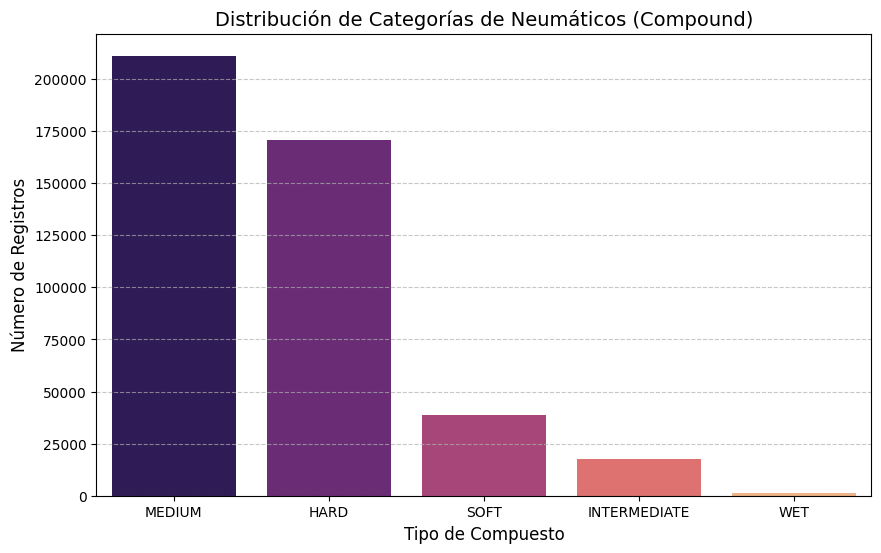

In [6]:
# Crear el gráfico de barras
plt.figure(figsize=(10, 6))
sns.barplot(x=compound_counts.index, y=compound_counts.values, hue=compound_counts.index, palette='magma', legend=False)

# Configuración de etiquetas y título
plt.title('Distribución de Categorías de Neumáticos (Compound)', fontsize=14)
plt.xlabel('Tipo de Compuesto', fontsize=12)
plt.ylabel('Número de Registros', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Mostrar el gráfico
plt.show()

## Race
La tabla muestra que el promedio de registros por Gran Premio es de aproximadamente 16,890. El Dutch Grand Prix es el que tiene mayor presencia con 24,462 registros, mientras que el French Grand Prix es el que menos tiene con 3,185. El gráfico de barras permite visualizar claramente cómo se distribuyen estas frecuencias entre las 20 carreras más populares.

--- Resumen Estadístico de Carreras ---


,Estadística,Valor
0,Promedio de Frecuencia,16890.0
1,Carrera Máxima,Dutch Grand Prix
2,Frecuencia Máxima,24462
3,Carrera Mínima,French Grand Prix
4,Frecuencia Mínima,3185


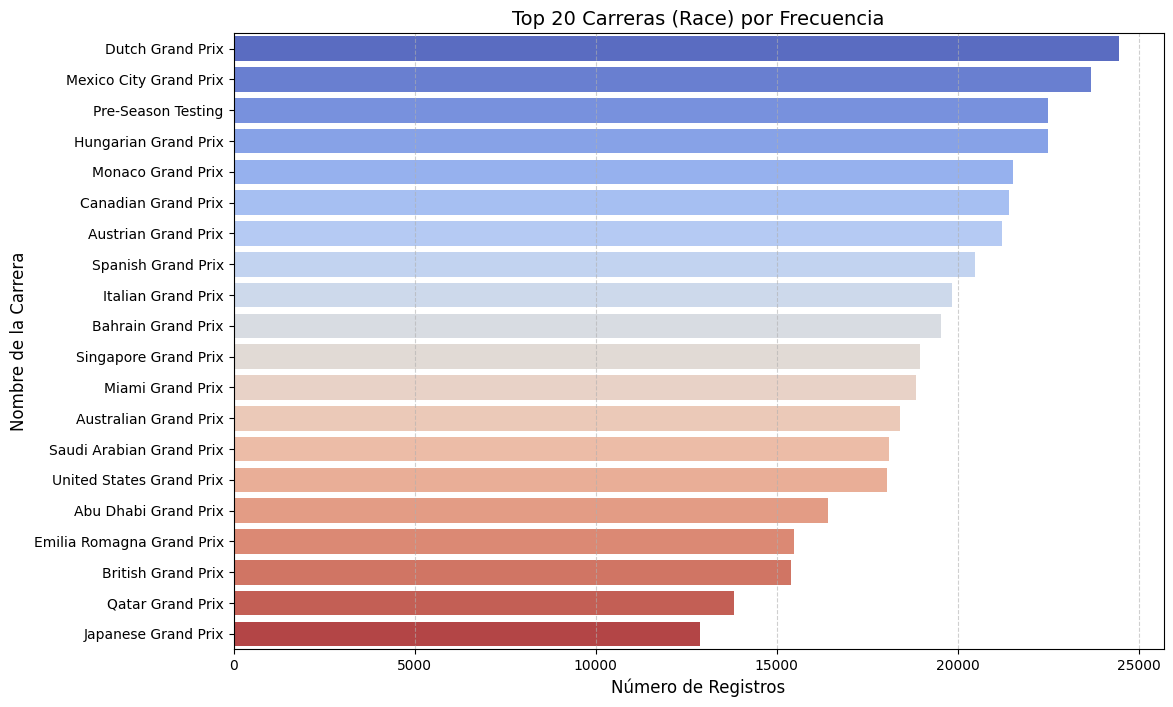

Existen un total de 26 categorías únicas en la columna Race.


In [7]:
# 1. Calcular las frecuencias de las carreras
race_counts = df['Race'].value_counts()

# 2. Calcular estadísticas
stats_race = pd.DataFrame({
    'Estadística': ['Promedio de Frecuencia', 'Carrera Máxima', 'Frecuencia Máxima', 'Carrera Mínima', 'Frecuencia Mínima'],
    'Valor': [
        round(race_counts.mean(), 2),
        race_counts.idxmax(),
        race_counts.max(),
        race_counts.idxmin(),
        race_counts.min()
    ]
})

print('--- Resumen Estadístico de Carreras ---')
display(stats_race)

# 3. Seleccionar las top 20 para la visualización
top_races = race_counts.head(20)

# 4. Crear el gráfico
plt.figure(figsize=(12, 8))
sns.barplot(y=top_races.index, x=top_races.values, hue=top_races.index, palette='coolwarm', legend=False)

plt.title('Top 20 Carreras (Race) por Frecuencia', fontsize=14)
plt.xlabel('Número de Registros', fontsize=12)
plt.ylabel('Nombre de la Carrera', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.show()

print(f'Existen un total de {df["Race"].nunique()} categorías únicas en la columna Race.')

## Year
Se muestran 4 periodos. Si bien hay diferencias en la cantidad de datos, no se espera que las diferencias sean determinantes.

In [8]:

# 1. Calcular las frecuencias por año y ordenar por índice (año)
year_counts = df['Year'].value_counts().sort_index()

# 2. Mostrar el resumen en una tabla
print('--- Frecuencia de registros por Año ---')
display(year_counts.to_frame(name='Número de Registros'))

# 3. Estadísticas básicas de los años
print(f'\nPeriodo cubierto: {df["Year"].min()} a {df["Year"].max()}')

--- Frecuencia de registros por Año ---


,Número de Registros
Year,
2022,82989
2023,136147
2024,127110
2025,92894



Periodo cubierto: 2022 a 2025


## PitStop
El código se ha actualizado y ahora podemos ver claramente las proporciones:

0 (Sin parada): 379,365 registros (86.39%)
1 (Parada en boxes): 59,775 registros (13.61%)

Esto es muy coherente para un dataset de F1, ya que los pilotos pasan la gran mayoría de las vueltas en pista y solo una pequeña fracción entrando a boxes.

**Adicionalmente, posteriormente despues del EDA general, se podría crear una nueva columna en donde se estipule la cantidad de vueltas corridas desde el inicio de la carrera o desde la ultima vez que se dio 1 (entrada a box). PERO esto solo podria considerare si es que los datos son secuenciales. Lo veremos mas adelante.**

In [10]:
print(f"Tipo de dato de PitStop: {df['PitStop'].dtype}")

# Obtener frecuencias y proporciones
pitstop_counts = df['PitStop'].value_counts(dropna=False).sort_index()
pitstop_proportions = df['PitStop'].value_counts(normalize=True, dropna=False).sort_index() * 100

# Crear un DataFrame para mostrar ambos
summary_pitstop = pd.DataFrame({
    'Conteo': pitstop_counts,
    'Proporción (%)': pitstop_proportions.map('{:.2f}%'.format)
})

print('\n--- Análisis de PitStop (Frecuencias y Proporciones) ---')
display(summary_pitstop)

# Verificar si es binario
unique_vals = df['PitStop'].unique()
if set(unique_vals).issubset({0, 1}):
    print("\n✅ Conclusión: La columna es categórica/binaria (contiene solo 0 y 1).")
else:
    print(f"\nℹ️ Conclusión: La columna contiene los siguientes valores: {unique_vals}")

Tipo de dato de PitStop: int64

--- Análisis de PitStop (Frecuencias y Proporciones) ---


,Conteo,Proporción (%)
PitStop,,
0,379365,86.39%
1,59775,13.61%



✅ Conclusión: La columna es categórica/binaria (contiene solo 0 y 1).


## LapNumber (Número de Vuelta)
Visualización de la frecuencia de registros distribuidos en 5 rangos (bins) desde la vuelta inicial hasta la final.

El gráfico muestra una tendencia muy clara: la gran mayoría de los registros se concentran en las primeras 16 vueltas (Bin 1, con casi 200,000 registros).

Esto es interesante porque indica que, a medida que la carrera avanza hacia la vuelta 78, el volumen de datos disminuye drásticamente. Esto suele ocurrir en datasets de F1 debido a abandonos (DNFs) o porque no todos los Grandes Premios tienen la misma duración (algunos terminan en la vuelta 50, otros en la 70).

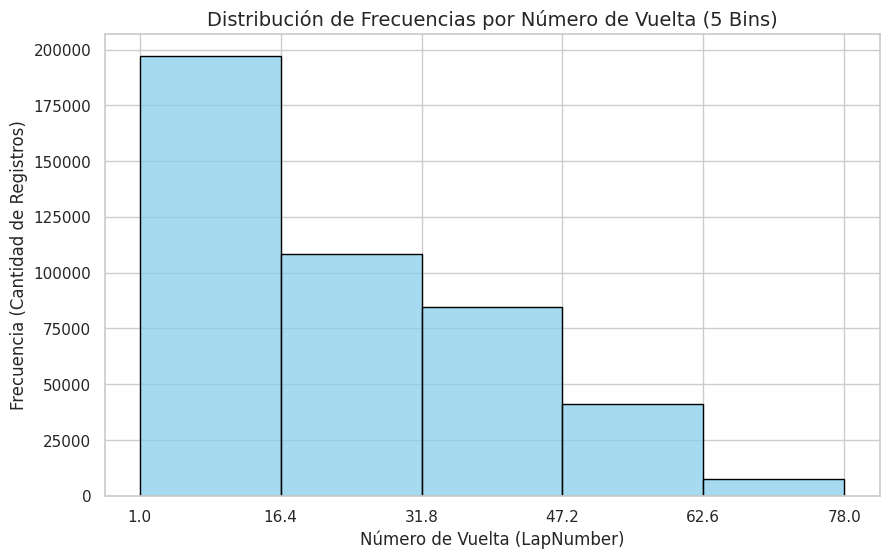

--- Detalles de los 5 Bins ---
Bin 1: Rango [1.0 - 16.4] -> 197243 registros
Bin 2: Rango [16.4 - 31.8] -> 108377 registros
Bin 3: Rango [31.8 - 47.2] -> 84724 registros
Bin 4: Rango [47.2 - 62.6] -> 41116 registros
Bin 5: Rango [62.6 - 78.0] -> 7680 registros


In [11]:
# Configurar el estilo
sns.set_theme(style="whitegrid")

# Crear el histograma con 5 bins
plt.figure(figsize=(10, 6))
sns.histplot(df['LapNumber'], bins=5, kde=False, color='skyblue', edgecolor='black')

# Personalización
plt.title('Distribución de Frecuencias por Número de Vuelta (5 Bins)', fontsize=14)
plt.xlabel('Número de Vuelta (LapNumber)', fontsize=12)
plt.ylabel('Frecuencia (Cantidad de Registros)', fontsize=12)

# Calcular los bordes de los bins para mayor claridad
bins_edges = np.linspace(df['LapNumber'].min(), df['LapNumber'].max(), 6)
plt.xticks(bins_edges)

plt.show()

# Mostrar los rangos exactos de los bins
counts, edges = np.histogram(df['LapNumber'], bins=5)
print("--- Detalles de los 5 Bins ---")
for i in range(len(counts)):
    print(f"Bin {i+1}: Rango [{edges[i]:.1f} - {edges[i+1]:.1f}] -> {counts[i]} registros")

## Stint

Esta variable indica cuántas veces un piloto ha cambiado de neumáticos durante la carrera (el número de tanda).

Aquí los hallazgos clave:

Stint 1: Es el más común con un 49.25% de los registros (216,288). Es lógico, ya que todos los pilotos inician la carrera con el primer set de neumáticos.

Stints 2 y 3: Representan el 29.50% y 15.77% respectivamente. Esto cubre la gran mayoría de las estrategias de carrera típicas (1 o 2 paradas).

Stints 6, 7 y 8: Son extremadamente raros (menos del 0.2% en total), ocurriendo probablemente en carreras con lluvia extrema o múltiples incidentes.

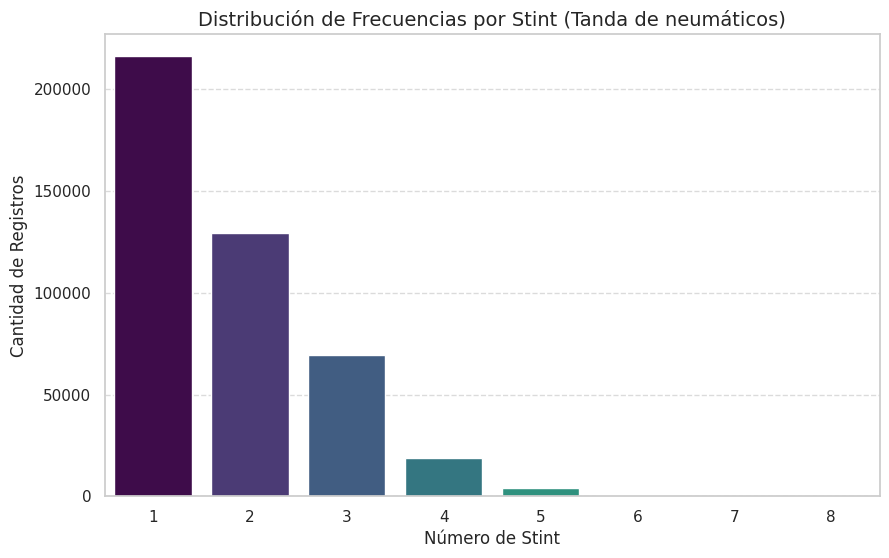

--- Resumen de Stints ---


,Registros,Porcentaje (%)
Stint,,
1,216288,49.25%
2,129536,29.50%
3,69238,15.77%
4,18903,4.30%
5,4281,0.97%
6,728,0.17%
7,116,0.03%
8,50,0.01%


In [12]:
# 1. Calcular las frecuencias de Stint
stint_counts = df['Stint'].value_counts().sort_index()

# 2. Crear la visualización
plt.figure(figsize=(10, 6))
sns.barplot(x=stint_counts.index, y=stint_counts.values, hue=stint_counts.index, palette='viridis', legend=False)

# Personalización del gráfico
plt.title('Distribución de Frecuencias por Stint (Tanda de neumáticos)', fontsize=14)
plt.xlabel('Número de Stint', fontsize=12)
plt.ylabel('Cantidad de Registros', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

# 3. Mostrar tabla de frecuencias y proporciones
stint_summary = pd.DataFrame({
    'Registros': stint_counts,
    'Porcentaje (%)': (df['Stint'].value_counts(normalize=True).sort_index() * 100).map('{:.2f}%'.format)
})

print('--- Resumen de Stints ---')
display(stint_summary)

## TyreLife (Vida del Neumático)
Fundamental para entender el desgaste de los neumáticos.

Estos son los puntos clave:

Los neumáticos duran, en promedio, 14.16 vueltas.

Alrededor del 81% de los datos se encuentran en los primeros dos bins (vueltas 1 a 22).

Valores Atípicos: Hay muy pocos registros con neumáticos de más de 50 vueltas de vida (Bins 6 y 7), lo cual es lógico ya que en la F1 es extremadamente raro y peligroso rodar tanto tiempo con el mismo set.

**El concepto de TyreLife es muy similar al valor de la columna que buscabamos crear a partir de la cantidad de vueltas que un auto corre desde el punto de inicio o desde que entro a un "box".**

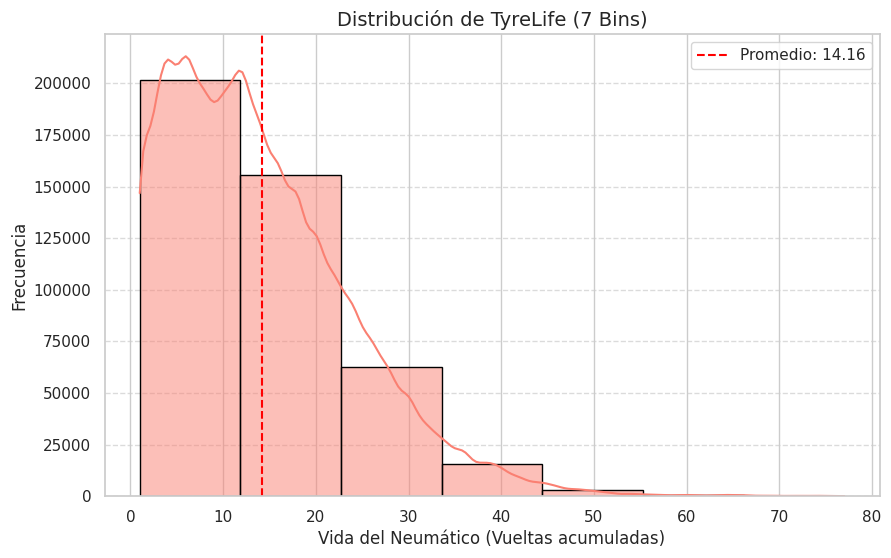

El promedio de TyreLife es: 14.16 vueltas

--- Detalles de los 7 Bins ---
Bin 1: Rango [1.0 - 11.9] -> 201431 registros
Bin 2: Rango [11.9 - 22.7] -> 155812 registros
Bin 3: Rango [22.7 - 33.6] -> 62824 registros
Bin 4: Rango [33.6 - 44.4] -> 15514 registros
Bin 5: Rango [44.4 - 55.3] -> 2798 registros
Bin 6: Rango [55.3 - 66.1] -> 579 registros
Bin 7: Rango [66.1 - 77.0] -> 182 registros


In [13]:
# 1. Calcular el promedio
tyre_life_avg = df['TyreLife'].mean()

# 2. Crear el gráfico
plt.figure(figsize=(10, 6))
sns.histplot(df['TyreLife'], bins=7, kde=True, color='salmon', edgecolor='black')

# Añadir línea del promedio
plt.axvline(tyre_life_avg, color='red', linestyle='--', label=f'Promedio: {tyre_life_avg:.2f}')

# Personalización
plt.title('Distribución de TyreLife (7 Bins)', fontsize=14)
plt.xlabel('Vida del Neumático (Vueltas acumuladas)', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

# 3. Mostrar detalles numéricos
counts, edges = np.histogram(df['TyreLife'], bins=7)
print(f"El promedio de TyreLife es: {tyre_life_avg:.2f} vueltas\n")
print("--- Detalles de los 7 Bins ---")
for i in range(len(counts)):
    print(f"Bin {i+1}: Rango [{edges[i]:.1f} - {edges[i+1]:.1f}] -> {counts[i]} registros")

## Position (Posición en Carrera)
Esta variable indica la posición en pista del piloto en cada vuelta.

El análisis de Position muestra que los datos están bastante bien distribuidos entre las posiciones 1 y 20, con una media de 9.63. Es notable que la frecuencia disminuye ligeramente en las posiciones más altas (18-20), lo que coincide con los abandonos que mencionamos antes.

--- Estadísticas de Position ---


,Position
count,439140.000000
mean,9.630339
std,5.278770
min,1.000000
25%,5.000000
50%,10.000000
75%,14.000000
max,20.000000


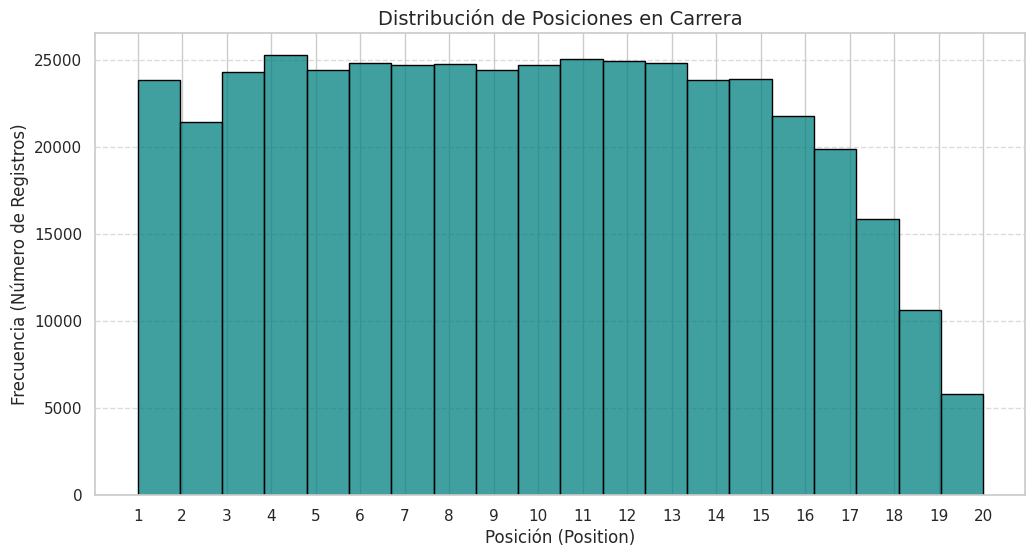

In [14]:
# 1. Estadísticas descriptivas de Position
print('--- Estadísticas de Position ---')
display(df['Position'].describe())

# 2. Visualización de la distribución
plt.figure(figsize=(12, 6))
sns.histplot(df['Position'], bins=20, kde=False, color='teal', edgecolor='black')

# Personalización
plt.title('Distribución de Posiciones en Carrera', fontsize=14)
plt.xlabel('Posición (Position)', fontsize=12)
plt.ylabel('Frecuencia (Número de Registros)', fontsize=12)
plt.xticks(range(1, 21))
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

## LapTime (s) (Tiempo de Vuelta)
Análisis de la distribución de los tiempos de vuelta en segundos.

Esto es muy útil porque nos permite ver exactamente en qué punto los tiempos dejan de ser 'normales' y empiezan a ser atípicos (vueltas muy lentas).

Como puedes ver en las estadísticas y en el gráfico, el 99% de las vueltas están por debajo de los 124.90 segundos. Esto confirma que el valor máximo de 2507 segundos es un outlier extremo.

--- Estadísticas de LapTime (s) ---


,LapTime (s)
count,439140.000000
mean,90.948735
std,19.772769
min,67.694000
25%,82.621000
50%,90.521000
75%,98.471000
90%,103.690000
95%,109.726050
99%,124.900000


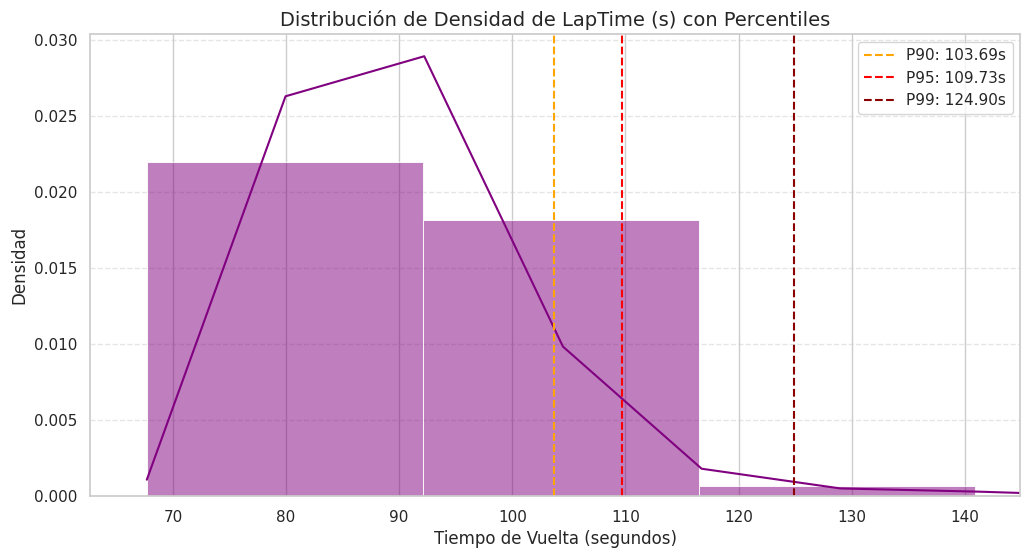

El 90% de las vueltas son menores a: 103.69s
El 95% de las vueltas son menores a: 109.73s
El 99% de las vueltas son menores a: 124.90s


In [15]:
# 1. Estadísticas descriptivas detalladas incluyendo percentiles altos
print('--- Estadísticas de LapTime (s) ---')
stats = df['LapTime (s)'].describe(percentiles=[.25, .5, .75, .9, .95, .99])
display(stats)

# Extraer percentiles específicos para visualización
p90 = df['LapTime (s)'].quantile(0.90)
p95 = df['LapTime (s)'].quantile(0.95)
p99 = df['LapTime (s)'].quantile(0.99)

# 2. Gráfico de densidad de frecuencias (Histograma + KDE)
plt.figure(figsize=(12, 6))
sns.histplot(df['LapTime (s)'], kde=True, color='purple', bins=100, stat="density")

# Añadir líneas de percentiles
plt.axvline(p90, color='orange', linestyle='--', label=f'P90: {p90:.2f}s')
plt.axvline(p95, color='red', linestyle='--', label=f'P95: {p95:.2f}s')
plt.axvline(p99, color='darkred', linestyle='--', label=f'P99: {p99:.2f}s')

# Personalización
plt.title('Distribución de Densidad de LapTime (s) con Percentiles', fontsize=14)
plt.xlabel('Tiempo de Vuelta (segundos)', fontsize=12)
plt.ylabel('Densidad', fontsize=12)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Limitar el eje X para que el gráfico sea legible a pesar de los outliers extremos
plt.xlim(df['LapTime (s)'].min() - 5, p99 + 20)

plt.show()

print(f"El 90% de las vueltas son menores a: {p90:.2f}s")
print(f"El 95% de las vueltas son menores a: {p95:.2f}s")
print(f"El 99% de las vueltas son menores a: {p99:.2f}s")

## LapTime_Delta
Análisis del cambio en los tiempos de vuelta entre registros consecutivos.

Esta columna mide el cambio de tiempo respecto a la vuelta anterior. Generalmente, los valores cercanos a cero indican consistencia, mientras que deltas grandes (positivos o negativos) suelen señalar paradas en boxes o incidentes.

El análisis de LapTime_Delta revela variaciones extremas, con un rango que va desde los -2403 hasta los +2423 segundos, lo cual refuerza la idea de que hay anomalías o incidentes graves en los datos. Sin embargo, el 98% de los registros (entre el percentil 1 y 99) se mantienen en un rango mucho más estrecho: de -40.26s a +30.93s. Los valores negativos grandes suelen ser la vuelta de salida de pits comparada con la de entrada.

--- Estadísticas de LapTime_Delta ---


,LapTime_Delta
count,439140.000000
mean,-3.770040
std,43.945759
min,-2403.895000
1%,-40.256880
25%,-8.884000
50%,-0.295000
75%,0.115000
99%,30.932000
max,2423.932000


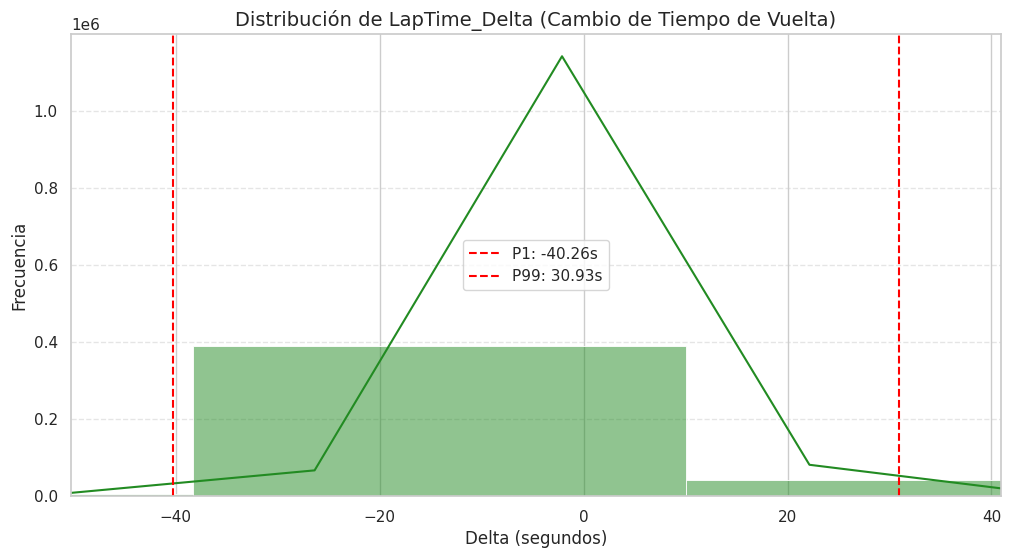

In [16]:
# 1. Estadísticas descriptivas de LapTime_Delta
print('--- Estadísticas de LapTime_Delta ---')
display(df['LapTime_Delta'].describe(percentiles=[.01, .25, .5, .75, .99]))

# 2. Visualización de la distribución
plt.figure(figsize=(12, 6))
sns.histplot(df['LapTime_Delta'], kde=True, color='forestgreen', bins=100)

# Añadir líneas para el percentil 1 y 99 para detectar límites de consistencia
p01 = df['LapTime_Delta'].quantile(0.01)
p99 = df['LapTime_Delta'].quantile(0.99)
plt.axvline(p01, color='red', linestyle='--', label=f'P1: {p01:.2f}s')
plt.axvline(p99, color='red', linestyle='--', label=f'P99: {p99:.2f}s')

# Personalización
plt.title('Distribución de LapTime_Delta (Cambio de Tiempo de Vuelta)', fontsize=14)
plt.xlabel('Delta (segundos)', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Limitar el eje X para observar el centro de la distribución ignorando outliers extremos
plt.xlim(p01 - 10, p99 + 10)

plt.show()

## Cumulative_Degradation
Visualización del desgaste acumulado de los neumáticos.

Al analizar esta distribución podemos observar si la degradación sigue un patrón lineal o si hay niveles críticos de desgaste donde se concentran la mayoría de los registros antes de un cambio de neumáticos.

El análisis de Cumulative_Degradation muestra que la mayoría de los valores son negativos (con una media de -25.72), lo cual es interesante ya que sugiere una métrica de 'pérdida' de rendimiento. Sin embargo, nuevamente vemos un valor máximo de 2412, que es un outlier masivo comparado con el tercer cuartil (-6.19).

--- Estadísticas de Cumulative_Degradation ---


,Cumulative_Degradation
count,439140.000000
mean,-25.721759
std,54.766573
min,-274.564000
25%,-46.566250
50%,-20.994000
75%,-6.199000
max,2412.026000


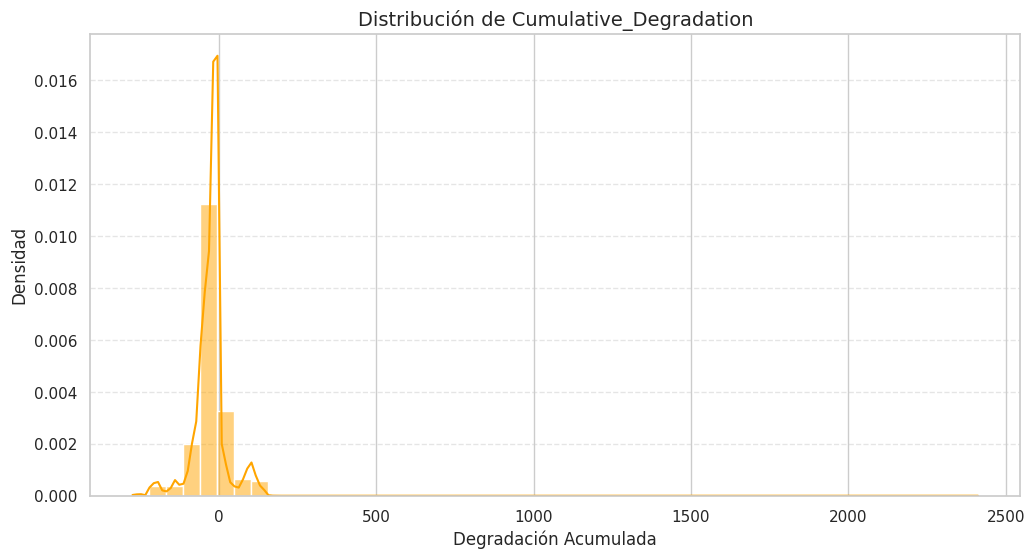

In [17]:
# 1. Estadísticas descriptivas de Cumulative_Degradation
print('--- Estadísticas de Cumulative_Degradation ---')
display(df['Cumulative_Degradation'].describe())

# 2. Visualización de la distribución
plt.figure(figsize=(12, 6))
sns.histplot(df['Cumulative_Degradation'], kde=True, color='orange', bins=50, stat='density')

# Personalización
plt.title('Distribución de Cumulative_Degradation', fontsize=14)
plt.xlabel('Degradación Acumulada', fontsize=12)
plt.ylabel('Densidad', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

Filtramos los datos para enfocarnos en el rango donde se encuentra el 99% de la actividad, ignorando los outliers extremos que dificultan la interpretación del gráfico.

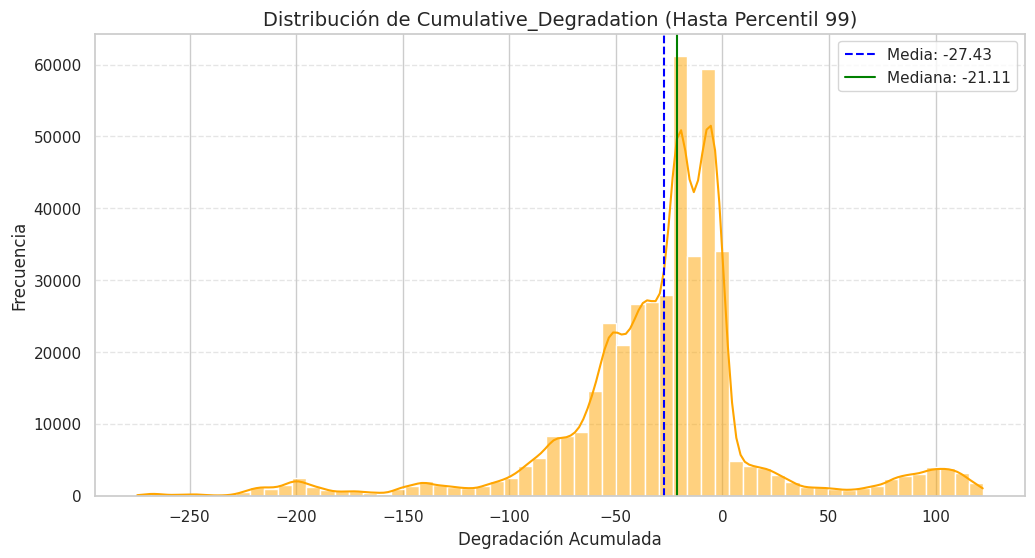

Límite del Percentil 99: 122.15
Rango visualizado: -274.56 a 122.15


In [18]:
# Calcular el percentil 99 para el filtrado
p99_degrad = df['Cumulative_Degradation'].quantile(0.99)

# Crear el subconjunto de datos
df_degrad_p99 = df[df['Cumulative_Degradation'] <= p99_degrad]

# Configurar el gráfico
plt.figure(figsize=(12, 6))
sns.histplot(df_degrad_p99['Cumulative_Degradation'], kde=True, color='orange', bins=60)

# Añadir líneas de referencia
plt.axvline(df_degrad_p99['Cumulative_Degradation'].mean(), color='blue', linestyle='--', label=f'Media: {df_degrad_p99["Cumulative_Degradation"].mean():.2f}')
plt.axvline(df_degrad_p99['Cumulative_Degradation'].median(), color='green', linestyle='-', label=f'Mediana: {df_degrad_p99["Cumulative_Degradation"].median():.2f}')

plt.title('Distribución de Cumulative_Degradation (Hasta Percentil 99)', fontsize=14)
plt.xlabel('Degradación Acumulada', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

print(f"Límite del Percentil 99: {p99_degrad:.2f}")
print(f"Rango visualizado: {df_degrad_p99['Cumulative_Degradation'].min():.2f} a {df_degrad_p99['Cumulative_Degradation'].max():.2f}")

### Distribución de RaceProgress
Analizamos cómo se distribuyen los registros a lo largo del progreso de las carreras (de 0 a 1).

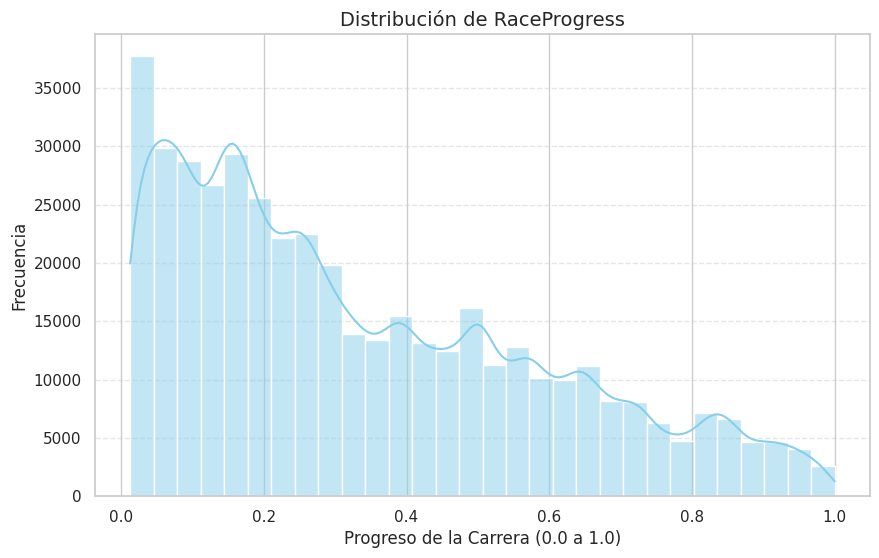

--- Resumen de RaceProgress ---
count    439140.000000
mean          0.337661
std           0.253277
min           0.012821
25%           0.129870
50%           0.269231
75%           0.513158
max           1.000000
Name: RaceProgress, dtype: float64


In [19]:
plt.figure(figsize=(10, 6))
sns.histplot(df['RaceProgress'], kde=True, color='skyblue', bins=30)

# Añadir detalles al gráfico
plt.title('Distribución de RaceProgress', fontsize=14)
plt.xlabel('Progreso de la Carrera (0.0 a 1.0)', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

# Resumen estadístico
print("--- Resumen de RaceProgress ---")
print(df['RaceProgress'].describe())

Hay una tendencia a la baja cuando se registran las freuencias de progreso de carrera. Esto indica que siemore estan retirandose Drivers de la pista, continuamente.

## Position_Change
Visualizamos la frecuencia de los cambios de posición (valores positivos indican posiciones ganadas, negativos indican perdidas).

La distribucion de datos (totalmente bell-shape) es la esperada. En la gran mayoria de las veces, no hay cambios o hay cambios pequeños de posiciones dentro de la misma carrera.

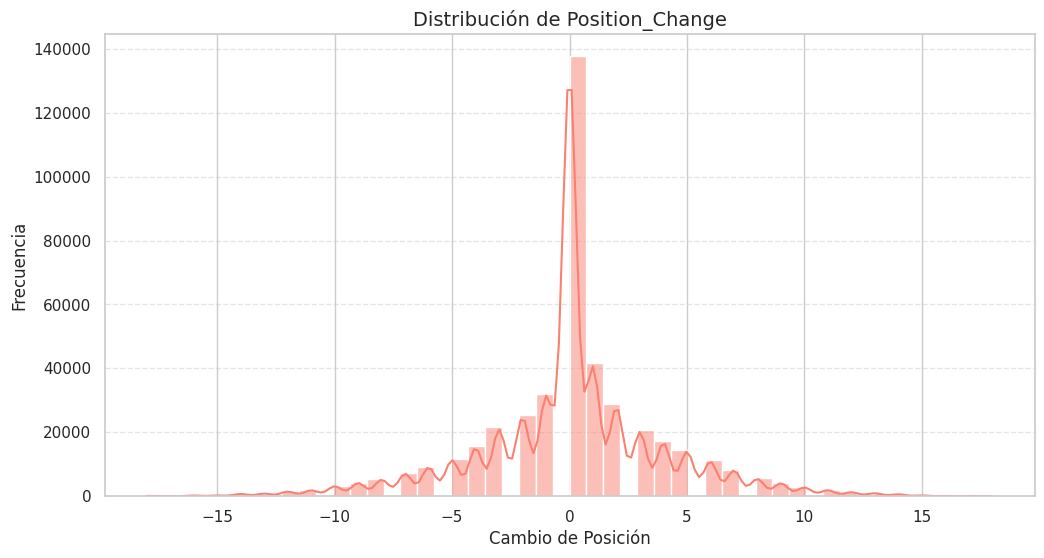

--- Resumen de Position_Change ---
count    439140.000000
mean          0.101542
std           4.006765
min         -18.000000
25%          -1.000000
50%           0.000000
75%           2.000000
max          18.000000
Name: Position_Change, dtype: float64


In [20]:
plt.figure(figsize=(12, 6))
sns.histplot(df['Position_Change'], bins=50, kde=True, color='salmon')

# Añadir detalles al gráfico
plt.title('Distribución de Position_Change', fontsize=14)
plt.xlabel('Cambio de Posición', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

# Resumen estadístico
print("--- Resumen de Position_Change ---")
print(df['Position_Change'].describe())

## PitNextLap (Variable Objetivo)
Analizamos la proporción de registros donde el piloto entra a boxes en la vuelta siguiente (1) frente a los que permanecen en pista (0).

/tmp/ipykernel_945/706620350.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='PitNextLap', data=df, palette='viridis')


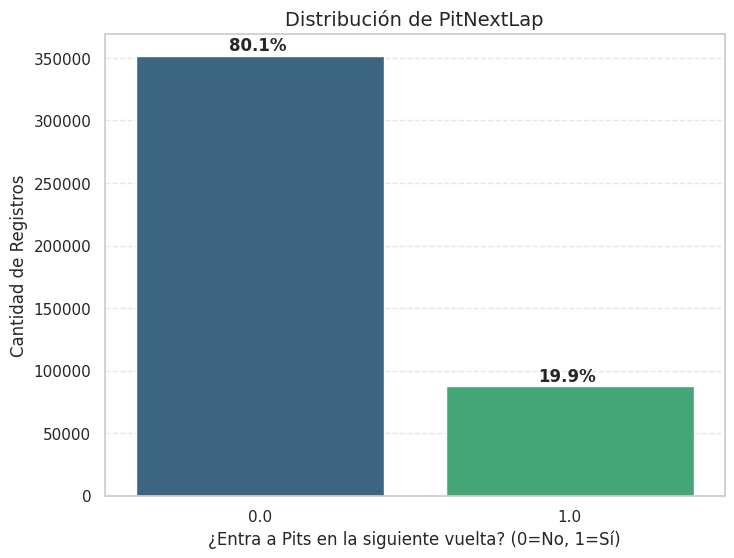

--- Proporción de PitNextLap ---
PitNextLap
0.0    80.10179
1.0    19.89821
Name: proportion, dtype: float64


In [21]:
plt.figure(figsize=(8, 6))
ax = sns.countplot(x='PitNextLap', data=df, palette='viridis')

# Añadir etiquetas de porcentaje
total = len(df)
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height()/total)
    x = p.get_x() + p.get_width() / 2 - 0.1
    y = p.get_height() + (total * 0.01)
    ax.annotate(percentage, (x, y), size=12, fontweight='bold')

plt.title('Distribución de PitNextLap', fontsize=14)
plt.xlabel('¿Entra a Pits en la siguiente vuelta? (0=No, 1=Sí)', fontsize=12)
plt.ylabel('Cantidad de Registros', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

# Proporción exacta en texto
print("--- Proporción de PitNextLap ---")
print(df['PitNextLap'].value_counts(normalize=True) * 100)

## Limpieza de Datos

Borramos la columna "id".

Necesitamos identificar los outliers maximos y saber cuantos son.

In [22]:
def count_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return len(outliers), lower_bound, upper_bound

# Columnas a analizar basadas en el EDA previo
columns_to_check = ['LapTime (s)', 'Cumulative_Degradation', 'LapTime_Delta']

outlier_summary = []

for col in columns_to_check:
    num, low, high = count_outliers_iqr(df, col)
    outlier_summary.append({
        'Columna': col,
        'Outliers Totales': num,
        'Porcentaje': f'{(num/len(df)*100):.2f}%',
        'Límite Inferior': low,
        'Límite Superior': high
    })

# Mostrar resultados
display(pd.DataFrame(outlier_summary))

# Borramos la columna 'id' como solicitaste
if 'id' in df.columns:
    df = df.drop(columns=['id'])
    print("✅ Columna 'id' eliminada correctamente.")

,Columna,Outliers Totales,Porcentaje,Límite Inferior,Límite Superior
0,LapTime (s),5905,1.34%,58.846000,122.246000
1,Cumulative_Degradation,49869,11.36%,-107.117125,54.351875
2,LapTime_Delta,58900,13.41%,-22.382500,13.613500


✅ Columna 'id' eliminada correctamente.


### Identificación de 'Lobos Solitarios' (Outliers Extremos)
Buscamos registros que estén más allá de $3 \times IQR$ o por encima del percentil 99.9, los cuales deforman visual y estadísticamente el dataset.

In [23]:
def find_extreme_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    # Usamos 3 * IQR para detectar lo realmente extremo
    extreme_limit = Q3 + 3 * IQR
    p999 = df[column].quantile(0.999)

    lone_wolves = df[df[column] > max(extreme_limit, p999)]
    return lone_wolves

# Analizamos la columna más problemática: LapTime (s)
lone_wolves_laptime = find_extreme_outliers(df, 'LapTime (s)')

print(f"--- Lobos Solitarios en LapTime (s) ---")
print(f"Registros encontrados: {len(lone_wolves_laptime)}")
if not lone_wolves_laptime.empty:
    display(lone_wolves_laptime[['Driver', 'Race', 'LapNumber', 'LapTime (s)']].sort_values(by='LapTime (s)', ascending=False).head(10))

# Analizamos Cumulative_Degradation
lone_wolves_degrad = find_extreme_outliers(df, 'Cumulative_Degradation')
print(f"\n--- Lobos Solitarios en Cumulative_Degradation ---")
print(f"Registros encontrados: {len(lone_wolves_degrad)}")
if not lone_wolves_degrad.empty:
    display(lone_wolves_degrad[['Driver', 'Race', 'Compound', 'Cumulative_Degradation']].sort_values(by='Cumulative_Degradation', ascending=False).head(5))

--- Lobos Solitarios en LapTime (s) ---
Registros encontrados: 437


,Driver,Race,LapNumber,LapTime (s)
419357,D076,Monaco Grand Prix,1,2507.607
245155,MAL,Monaco Grand Prix,1,2502.809
248029,BUE,Monaco Grand Prix,1,2502.648
358055,D114,Las Vegas Grand Prix,1,2497.820
237295,FIS,Monaco Grand Prix,1,2497.678
183041,FON,Monaco Grand Prix,1,2497.268
256648,HAR,Monaco Grand Prix,1,2488.809
255988,PIQ,Monaco Grand Prix,1,2488.609
382307,HIL,Monaco Grand Prix,1,2488.541
280886,LOP,Azerbaijan Grand Prix,1,2483.807



--- Lobos Solitarios en Cumulative_Degradation ---
Registros encontrados: 395


,Driver,Race,Compound,Cumulative_Degradation
138299,D021,Monaco Grand Prix,HARD,2412.026
411437,D093,Belgian Grand Prix,HARD,2410.000
358055,D114,Las Vegas Grand Prix,MEDIUM,2406.800
75838,WAR,Monaco Grand Prix,HARD,2406.800
248029,BUE,Monaco Grand Prix,HARD,2390.333


### Análisis de Aislamiento (Saltos de Magnitud)
Evaluamos si los valores máximos están conectados por una secuencia o si hay huecos masivos de información entre ellos.

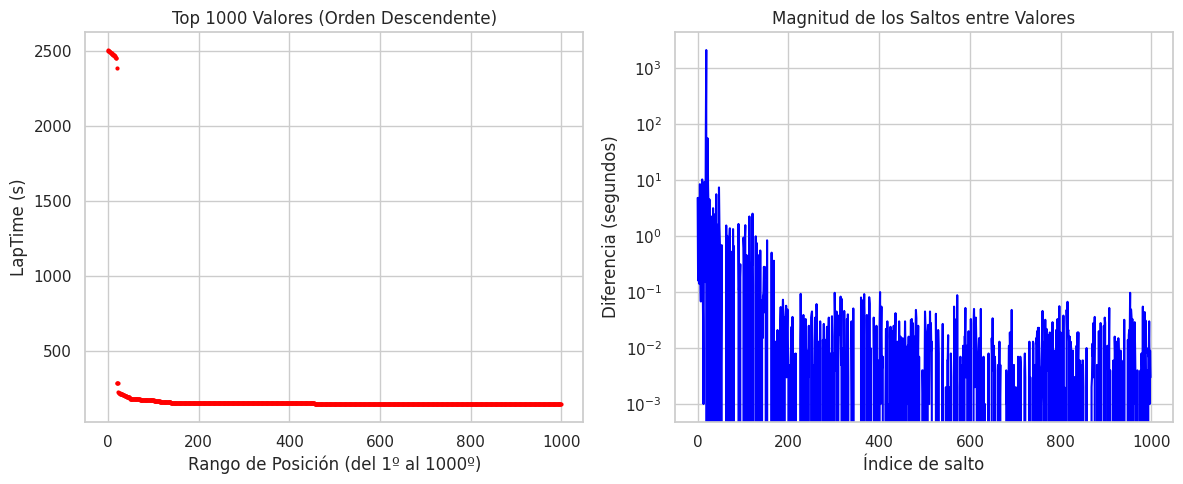

--- Los 5 mayores saltos detectados ---
Valor A: 2507.61s | Valor B: 2502.81s | Salto (Valle): 4.80s
Valor A: 2502.81s | Valor B: 2502.65s | Salto (Valle): 0.16s
Valor A: 2502.65s | Valor B: 2497.82s | Salto (Valle): 4.83s
Valor A: 2497.82s | Valor B: 2497.68s | Salto (Valle): 0.14s
Valor A: 2497.68s | Valor B: 2497.27s | Salto (Valle): 0.41s


In [24]:
# 1. Extraemos los 1000 valores más altos de LapTime (s) y los ordenamos
top_values = df['LapTime (s)'].sort_values(ascending=False).head(1000).values

# 2. Calculamos la diferencia entre cada valor y el que le sigue (el salto)
diffs = np.abs(np.diff(top_values))

# 3. Visualizamos la distribución de los valores para ver los 'valles'
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(top_values, 'o', markersize=2, color='red')
plt.title('Top 1000 Valores (Orden Descendente)')
plt.ylabel('LapTime (s)')
plt.xlabel('Rango de Posición (del 1º al 1000º)')

plt.subplot(1, 2, 2)
plt.plot(diffs, color='blue')
plt.yscale('log') # Escala logarítmica para ver mejor los saltos grandes
plt.title('Magnitud de los Saltos entre Valores')
plt.ylabel('Diferencia (segundos)')
plt.xlabel('Índice de salto')

plt.tight_layout()
plt.show()

# 4. Identificamos los saltos más grandes
print("--- Los 5 mayores saltos detectados ---")
# Mostramos el valor actual, el siguiente y el 'hueco' entre ellos
for i in range(5):
    print(f"Valor A: {top_values[i]:.2f}s | Valor B: {top_values[i+1]:.2f}s | Salto (Valle): {diffs[i]:.2f}s")

In [25]:
df_1 = df.copy()

### Limpieza de 'Lobos Solitarios' en df_1
Eliminamos los registros con `LapTime (s) > 2000` en la copia de trabajo para estabilizar las distribuciones sin perder el dataset original.

--- Resultado de la Limpieza en df_1 ---
Registros eliminados: 20
Nuevo valor máximo en LapTime (s): 282.08s


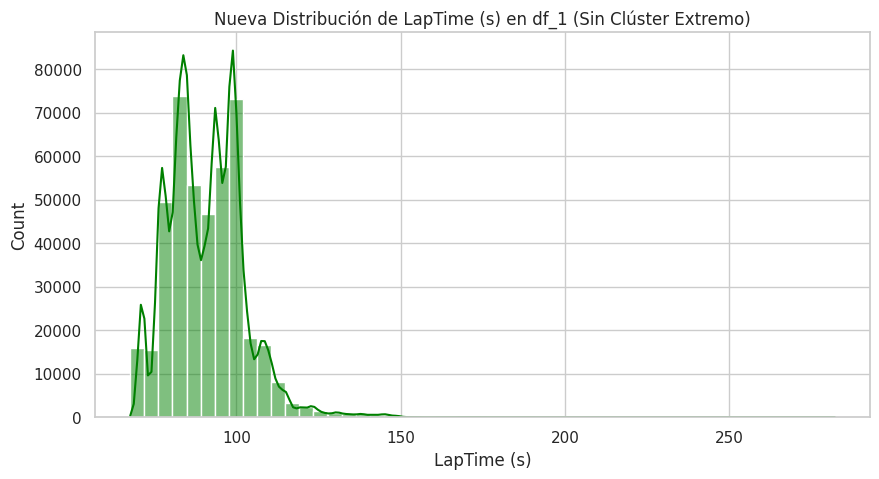

In [26]:
# 1. Contar registros antes de la eliminación
registros_antes = len(df_1)

# 2. Filtrar el clúster extremo (los lobos solitarios de ~2500s)
# Usamos 1000s como umbral ya que el 'valle' llegaba hasta los 282s
df_1 = df_1[df_1['LapTime (s)'] < 1000]

# 3. Verificar resultados
registros_despues = len(df_1)
eliminados = registros_antes - registros_despues

print(f"--- Resultado de la Limpieza en df_1 ---")
print(f"Registros eliminados: {eliminados}")
print(f"Nuevo valor máximo en LapTime (s): {df_1['LapTime (s)'].max():.2f}s")

# 4. Visualización rápida de la nueva distribución
plt.figure(figsize=(10, 5))
sns.histplot(df_1['LapTime (s)'], bins=50, kde=True, color='green')
plt.title('Nueva Distribución de LapTime (s) en df_1 (Sin Clúster Extremo)')
plt.show()

### Análisis de Aislamiento en Cumulative_Degradation
Identificamos si existen valles o saltos masivos de magnitud en el desgaste acumulado.

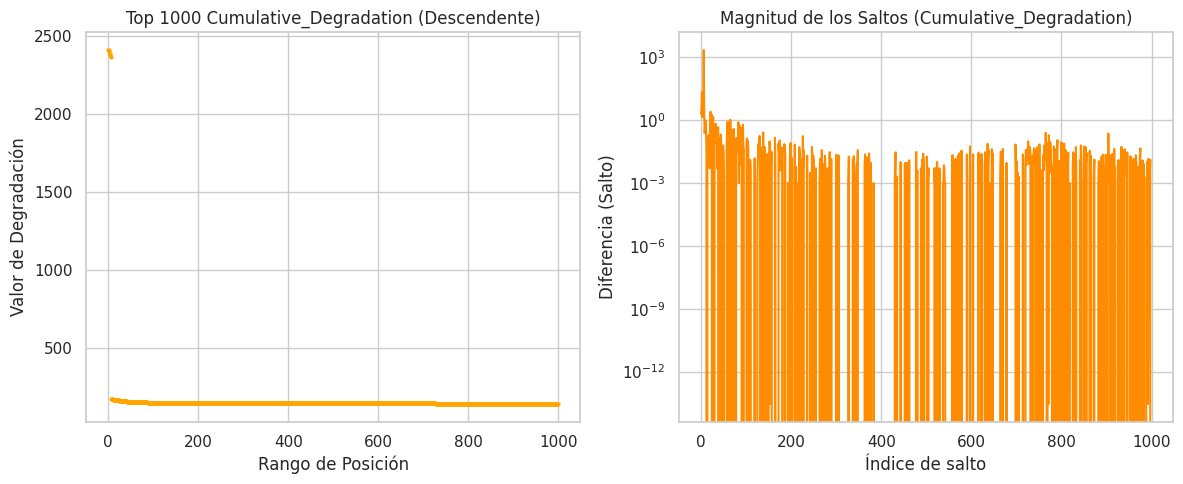

--- Mayores saltos detectados en Cumulative_Degradation ---
Valor A: 2412.03 | Valor B: 2410.00 | Salto: 2.03
Valor A: 2410.00 | Valor B: 2406.80 | Salto: 3.20
Valor A: 2406.80 | Valor B: 2385.06 | Salto: 21.74
Valor A: 2385.06 | Valor B: 2383.68 | Salto: 1.38
Valor A: 2383.68 | Valor B: 2381.26 | Salto: 2.42


In [27]:
# 1. Extraemos los 1000 valores más altos de Cumulative_Degradation y los ordenamos
top_degrad_values = df_1['Cumulative_Degradation'].sort_values(ascending=False).head(1000).values

# 2. Calculamos la diferencia entre cada valor y el siguiente
degrad_diffs = np.abs(np.diff(top_degrad_values))

# 3. Visualización
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(top_degrad_values, 'o', markersize=2, color='orange')
plt.title('Top 1000 Cumulative_Degradation (Descendente)')
plt.ylabel('Valor de Degradación')
plt.xlabel('Rango de Posición')

plt.subplot(1, 2, 2)
plt.plot(degrad_diffs, color='darkorange')
plt.yscale('log')
plt.title('Magnitud de los Saltos (Cumulative_Degradation)')
plt.ylabel('Diferencia (Salto)')
plt.xlabel('Índice de salto')

plt.tight_layout()
plt.show()

# 4. Identificar los mayores saltos
print("--- Mayores saltos detectados en Cumulative_Degradation ---")
for i in range(5):
    print(f"Valor A: {top_degrad_values[i]:.2f} | Valor B: {top_degrad_values[i+1]:.2f} | Salto: {degrad_diffs[i]:.2f}")

### Limpieza Final de Cumulative_Degradation en df_1
Basándonos en el análisis de saltos, eliminaremos los registros que superan el umbral de 500 para limpiar el clúster de valores extremos (~2400) y estabilizar el dataset para el modelado.

--- Limpieza de Degradación en df_1 ---
Registros eliminados del clúster extremo: 7
Nuevo valor máximo de Cumulative_Degradation: 175.51


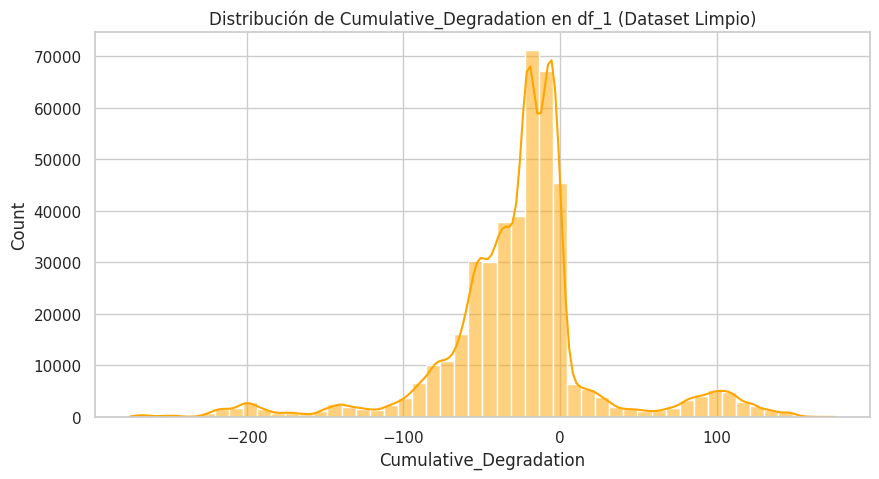

In [28]:
# 1. Contar registros antes de la limpieza
antes_degrad = len(df_1)

# 2. Aplicar filtro en df_1 (eliminando el clúster extremo de ~2400)
df_1 = df_1[df_1['Cumulative_Degradation'] < 500]

# 3. Resultados
despues_degrad = len(df_1)
eliminados_degrad = antes_degrad - despues_degrad

print(f"--- Limpieza de Degradación en df_1 ---")
print(f"Registros eliminados del clúster extremo: {eliminados_degrad}")
print(f"Nuevo valor máximo de Cumulative_Degradation: {df_1['Cumulative_Degradation'].max():.2f}")

# 4. Visualización de la distribución limpia
plt.figure(figsize=(10, 5))
sns.histplot(df_1['Cumulative_Degradation'], bins=50, kde=True, color='orange')
plt.title('Distribución de Cumulative_Degradation en df_1 (Dataset Limpio)')
plt.show()

resumen de la limpieza realizada hasta el momento en el dataset df_1:

Limpieza de LapTime (s): Se eliminaron 20 registros que formaban el clúster extremo (~2500s).

Limpieza de Cumulative_Degradation: Se eliminaron 7 registros adicionales del clúster de ruido (~2400).

Total de filas eliminadas: 27 filas.
Filas restantes en df_1: 439,113 filas.
El dataset df_1 ahora está libre de estos valores extremos que distorsionaban las estadísticas.

## Análisis de Secuencialidad de Vueltas
Evaluamos qué porcentaje de los datos representa una secuencia continua vuelta a vuelta.

--- Análisis de Secuencialidad en df_1 ---
Total de registros evaluados: 439,113

✅ Secuenciales directos (Diff = 1): 127,239 filas (28.98%)
⚠️ Saltos (Diff > 1): 271,005 filas (61.72%)
ℹ️ Inicios de registro (Sin vuelta previa): 40,869 filas (9.31%)

-> Conclusión: El 28.98% de tus datos fluye de manera continua (vuelta a vuelta).
-> El 71.02% restante corresponde a interrupciones o al primer dato disponible por piloto/carrera.


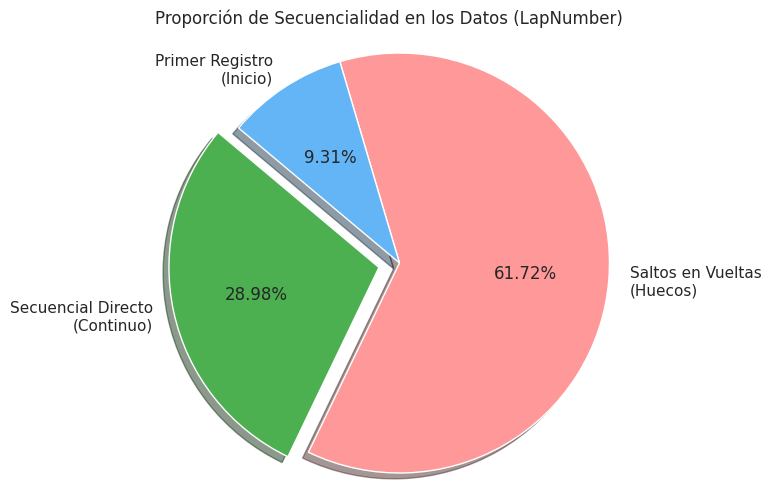

In [29]:
# 1. Aseguramos el orden correcto de los datos
df_1 = df_1.sort_values(by=['Year', 'Race', 'Driver', 'LapNumber'])

# 2. Calculamos la diferencia de LapNumber respecto a la fila anterior del mismo piloto/carrera
df_1['LapNumber_Diff'] = df_1.groupby(['Year', 'Race', 'Driver'])['LapNumber'].diff()

# 3. Categorizamos cada fila
# - Si la diferencia es 1, es secuencial directa
# - Si la diferencia es > 1, es un salto (no secuencial)
# - Si es NaN, es el primer registro de ese piloto en esa carrera (inicio)
total_filas = len(df_1)
secuenciales = (df_1['LapNumber_Diff'] == 1).sum()
saltos = (df_1['LapNumber_Diff'] > 1).sum()
inicios = df_1['LapNumber_Diff'].isna().sum()

# 4. Calculamos porcentajes
pct_secuencial = (secuenciales / total_filas) * 100
pct_saltos = (saltos / total_filas) * 100
pct_inicios = (inicios / total_filas) * 100

# 5. Mostramos los resultados
print("--- Análisis de Secuencialidad en df_1 ---")
print(f"Total de registros evaluados: {total_filas:,.0f}\n")
print(f"✅ Secuenciales directos (Diff = 1): {secuenciales:,.0f} filas ({pct_secuencial:.2f}%)")
print(f"⚠️ Saltos (Diff > 1): {saltos:,.0f} filas ({pct_saltos:.2f}%)")
print(f"ℹ️ Inicios de registro (Sin vuelta previa): {inicios:,.0f} filas ({pct_inicios:.2f}%)\n")

print(f"-> Conclusión: El {pct_secuencial:.2f}% de tus datos fluye de manera continua (vuelta a vuelta).")
print(f"-> El {(pct_saltos + pct_inicios):.2f}% restante corresponde a interrupciones o al primer dato disponible por piloto/carrera.")

# Visualización
import matplotlib.pyplot as plt

labels = ['Secuencial Directo\n(Continuo)', 'Saltos en Vueltas\n(Huecos)', 'Primer Registro\n(Inicio)']
sizes = [secuenciales, saltos, inicios]
colors = ['#4CAF50', '#FF9999', '#64B5F6']
explode = (0.1, 0, 0)

plt.figure(figsize=(8, 6))
plt.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.2f%%', shadow=True, startangle=140)
plt.title('Proporción de Secuencialidad en los Datos (LapNumber)')
plt.axis('equal')
plt.show()

Los datos no son secuenciales (solo en 30%). Esto nos sugiere que no podremos aplicar modelos con base secuenciales. Adicionalmente, no podremos crear una nueva columna en donde nos detalle cuantas vueltas se han dado desde que inicio la carrera o desde que se entro al box para cambiar neumaticos (esto resetea el conteo).

## CORRELACIONES

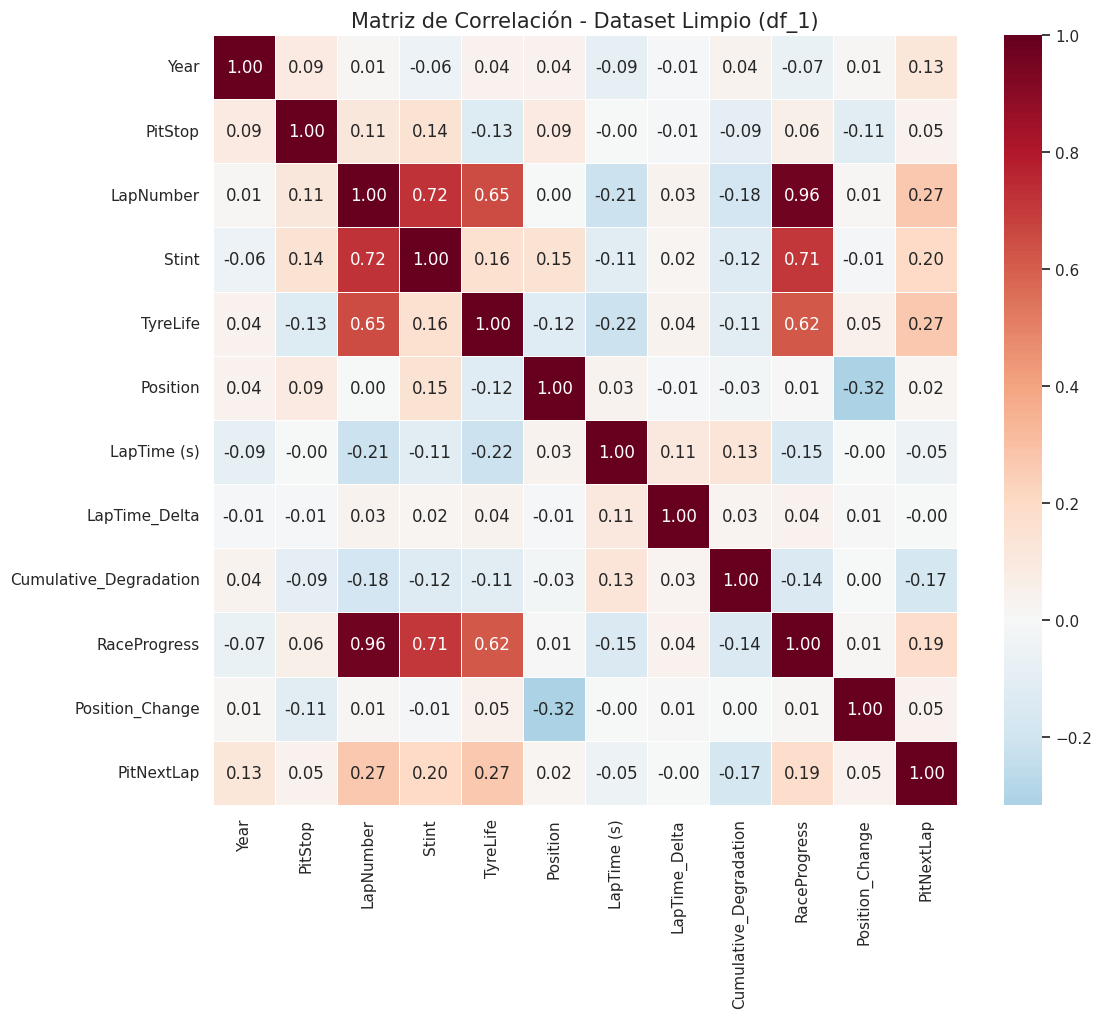

--- Correlación con PitNextLap en df_1 ---


,PitNextLap
PitNextLap,1.000000
TyreLife,0.273496
LapNumber,0.267042
Stint,0.198180
RaceProgress,0.185457
Year,0.125284
PitStop,0.048573
Position_Change,0.046233
Position,0.021338
LapTime_Delta,-0.004930


In [ ]:
import numpy as np

# 1. Seleccionar columnas numéricas del dataset limpio (df_1)
numeric_df_1 = df_1.select_dtypes(include=[np.number])

# 2. Calcular la matriz de correlación
corr_matrix_1 = numeric_df_1.corr()

# 3. Configurar y mostrar el mapa de calor
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix_1, annot=True, cmap='RdBu_r', center=0, fmt='.2f', linewidths=0.5)
plt.title('Matriz de Correlación - Dataset Limpio (df_1)', fontsize=15)
plt.show()

# 4. Mostrar las correlaciones específicas con la variable objetivo
print("--- Correlación con PitNextLap en df_1 ---")
display(corr_matrix_1['PitNextLap'].sort_values(ascending=False).to_frame())

Interpretación de Correlaciones (PitNextLap)

TyreLife (0.27) y LapNumber (0.27): Son los predictores positivos más fuertes. Esto confirma que a medida que aumenta el número de vueltas en la carrera y, sobre todo, la vida del neumático actual, la probabilidad de entrar a boxes aumenta de forma lineal.

Stint (0.20) y RaceProgress (0.19): Existe una correlación moderada. Los pilotos tienen más probabilidades de entrar a pits en etapas más avanzadas de la carrera o cuando ya han pasado por varios cambios de neumáticos.

Cumulative_Degradation (-0.17): Al ser una correlación negativa y dado que los valores de degradación suelen ser negativos (pérdida de rendimiento), esto indica que a mayor pérdida acumulada de rendimiento, más cerca está el piloto de su siguiente parada.

Variables con bajo impacto: Sorprendentemente, la Position (0.02) y el LapTime (s) (-0.05) tienen una correlación casi nula. Esto sugiere que las paradas se deciden más por la estrategia de desgaste y progreso de carrera que por la posición específica o el tiempo de una vuelta aislada.

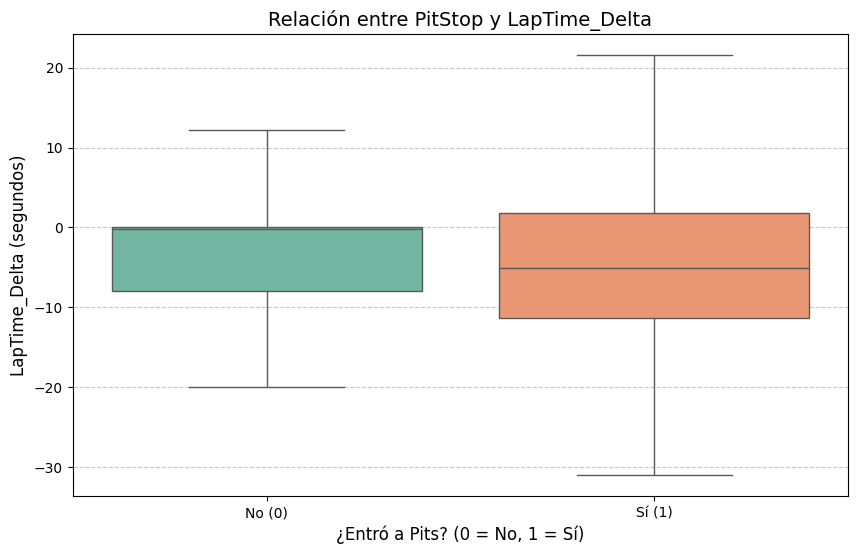

In [26]:
# ANALIZAMOS LAS VARIABLES DE PITSTOP y LapTime_Delta por curiosidad

plt.figure(figsize=(10, 6))
# Utilizamos showfliers=False para que los outliers extremos no distorsionen la visualización de las cajas
sns.boxplot(data=df_1, x='PitStop', y='LapTime_Delta', hue='PitStop', palette='Set2', showfliers=False, legend=False)

plt.title('Relación entre PitStop y LapTime_Delta', fontsize=14)
plt.xlabel('¿Entró a Pits? (0 = No, 1 = Sí)', fontsize=12)
plt.ylabel('LapTime_Delta (segundos)', fontsize=12)
plt.xticks([0, 1], ['No (0)', 'Sí (1)'])
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

Como se puede observar en el boxplot, la dispersión (y la mediana) del `LapTime_Delta` es significativamente mayor y más variable cuando el piloto entra a boxes (`PitStop = 1`). Esto confirma la hipótesis de que entrar al box genera un impacto (un delta) mucho mayor en el tiempo de vuelta en comparación con mantenerse en pista.

--- Tabla de Frecuencias y Porcentajes: Compound vs PitNextLap ---


,No Entra (0),Entra a Pits (1),% Entra a Pits
Compound,,,
HARD,114656,55851,32.76%
MEDIUM,189774,21352,10.11%
SOFT,31248,7496,19.35%
INTERMEDIATE,14735,2647,15.23%
WET,1320,34,2.51%


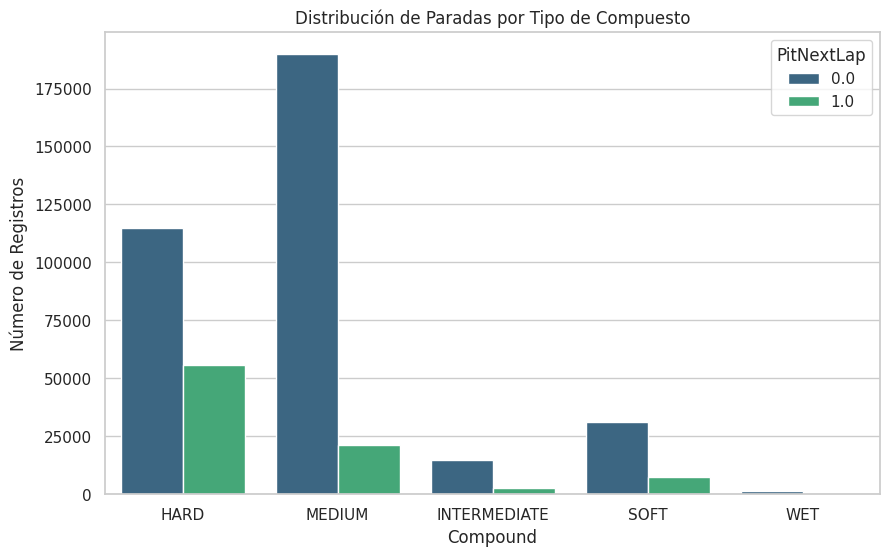

In [ ]:
# 1. Crear tabla de frecuencias (crosstab)
compound_pit_freq = pd.crosstab(df_1['Compound'], df_1['PitNextLap'])

# 2. Calcular porcentajes por fila (proporción de paradas por cada compuesto)
compound_pit_pct = pd.crosstab(df_1['Compound'], df_1['PitNextLap'], normalize='index') * 100

# 3. Combinar ambos para una tabla resumen profesional
summary_compound_pit = pd.DataFrame({
    'No Entra (0)': compound_pit_freq[0.0],
    'Entra a Pits (1)': compound_pit_freq[1.0],
    '% Entra a Pits': compound_pit_pct[1.0].map('{:.2f}%'.format)
})

print('--- Tabla de Frecuencias y Porcentajes: Compound vs PitNextLap ---')
display(summary_compound_pit.sort_values(by='Entra a Pits (1)', ascending=False))

# Visualización complementaria
plt.figure(figsize=(10, 6))
sns.countplot(x='Compound', hue='PitNextLap', data=df_1, palette='viridis')
plt.title('Distribución de Paradas por Tipo de Compuesto')
plt.ylabel('Número de Registros')
plt.show()

Es evidente que los neumaticos tipo "Hard" son los que mas ingresan a Box. El grafico de barras indica que un 33% de los carros con neumaticos HARD ingresan a box. Debemos confirmar esta tendencia no es porque los autos empiecen a correr con neumaticos HARD, dado que todos los autos ingresan al menos una vez a Box.

--- Neumáticos (Compound) al Inicio de la Carrera ---


,Autos que inician con este Compuesto,Porcentaje (%)
Compound,,
MEDIUM,26636,65.17%
HARD,7290,17.84%
SOFT,4997,12.23%
INTERMEDIATE,1736,4.25%
WET,210,0.51%


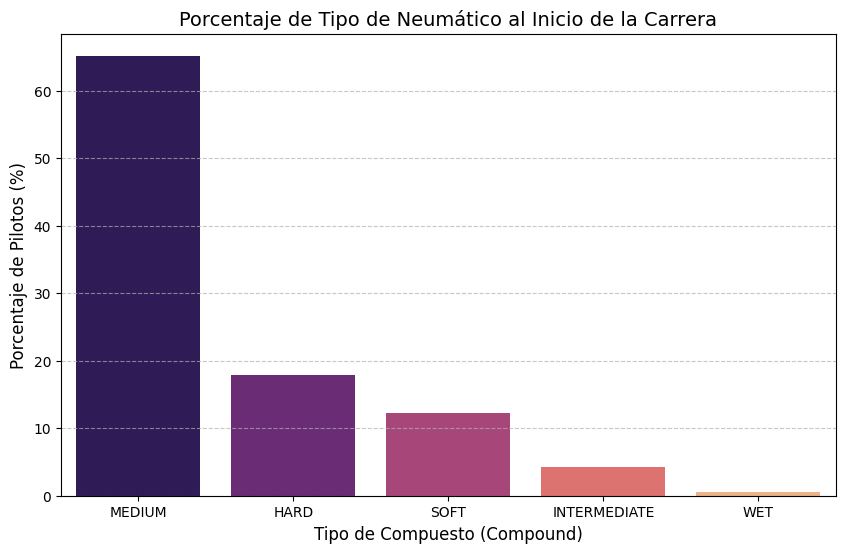

In [28]:
# 1. Ordenar por año, carrera, piloto y número de vuelta
df_sorted = df_1.sort_values(by=['Year', 'Race', 'Driver', 'LapNumber'])

# 2. Obtener el primer registro de cada piloto en cada carrera (el inicio)
starts_df = df_sorted.drop_duplicates(subset=['Year', 'Race', 'Driver'], keep='first')

# 3. Calcular la cantidad y el porcentaje de cada compuesto al inicio
start_counts = starts_df['Compound'].value_counts()
start_pct = starts_df['Compound'].value_counts(normalize=True) * 100

# 4. Crear tabla de resumen
summary_starts = pd.DataFrame({
    'Autos que inician con este Compuesto': start_counts,
    'Porcentaje (%)': start_pct.map('{:.2f}%'.format)
})

print('--- Neumáticos (Compound) al Inicio de la Carrera ---')
display(summary_starts)

# 5. Visualizar los resultados
plt.figure(figsize=(10, 6))
sns.barplot(x=start_pct.index, y=start_pct.values, hue=start_pct.index, palette='magma', legend=False)
plt.title('Porcentaje de Tipo de Neumático al Inicio de la Carrera', fontsize=14)
plt.xlabel('Tipo de Compuesto (Compound)', fontsize=12)
plt.ylabel('Porcentaje de Pilotos (%)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Qued confirmado que la mayoria de los neumaticos empiezan a correr con el compound Medium. Esto confirma aun mas la hipotesis de que los autos con compound HARD tienden a ingresar mas a Box que los neumaticos Medium.

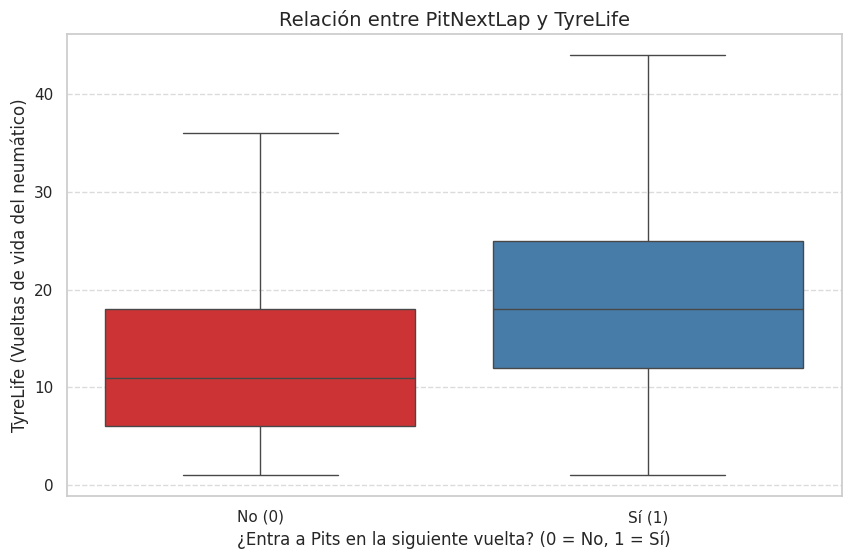

In [30]:
# ¿Que tan importante es TyreLife? Es el valor que mas corresponde al target.

plt.figure(figsize=(10, 6))
# Usamos showfliers=False para ver mejor la distribución principal
sns.boxplot(data=df_1, x='PitNextLap', y='TyreLife', hue='PitNextLap', palette='Set1', showfliers=False, legend=False)

plt.title('Relación entre PitNextLap y TyreLife', fontsize=14)
plt.xlabel('¿Entra a Pits en la siguiente vuelta? (0 = No, 1 = Sí)', fontsize=12)
plt.ylabel('TyreLife (Vueltas de vida del neumático)', fontsize=12)
plt.xticks([0, 1], ['No (0)', 'Sí (1)'])
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

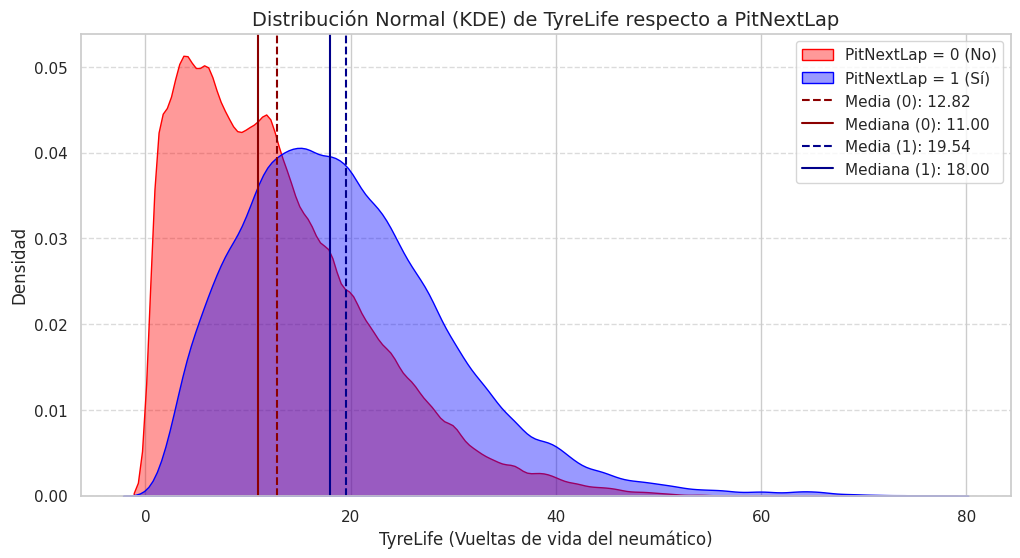

In [35]:
plt.figure(figsize=(12, 6))

# Separar los datos por categoría
tyrelife_0 = df_1[df_1['PitNextLap'] == 0]['TyreLife']
tyrelife_1 = df_1[df_1['PitNextLap'] == 1]['TyreLife']

# Generar los gráficos de densidad (KDE) con transparencia (alpha)
sns.kdeplot(tyrelife_0, fill=True, color='red', alpha=0.4, label='PitNextLap = 0 (No)')
sns.kdeplot(tyrelife_1, fill=True, color='blue', alpha=0.4, label='PitNextLap = 1 (Sí)')

# Calcular medias y medianas
mean_0, median_0 = tyrelife_0.mean(), tyrelife_0.median()
mean_1, median_1 = tyrelife_1.mean(), tyrelife_1.median()

# Añadir líneas para la media y mediana del grupo 0
plt.axvline(mean_0, color='darkred', linestyle='--', label=f'Media (0): {mean_0:.2f}')
plt.axvline(median_0, color='darkred', linestyle='-', label=f'Mediana (0): {median_0:.2f}')

# Añadir líneas para la media y mediana del grupo 1
plt.axvline(mean_1, color='darkblue', linestyle='--', label=f'Media (1): {mean_1:.2f}')
plt.axvline(median_1, color='darkblue', linestyle='-', label=f'Mediana (1): {median_1:.2f}')

# Personalizar el gráfico
plt.title('Distribución Normal (KDE) de TyreLife respecto a PitNextLap', fontsize=14)
plt.xlabel('TyreLife (Vueltas de vida del neumático)', fontsize=12)
plt.ylabel('Densidad', fontsize=12)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

La distribucion de los datos de la columna "TyreLife" en relacion a "PitNextLap" (1 o 0) muestran claras diferencias. Es evidente que hay mas posibilidades de entrar al Box cuando se tiene mas tiempo corriendo. Las diferencias entre medianas y promedios es de 7 vueltas aprox. El peak mas alto de los autos que ingresan a Box es de 15 vueltas y no comienza a descender en su posibilidad de ingresar a Box si no es a partir de tener 20 vueltas manejando. Esto puede estar relacionada a que el auto esté en el ultimo sprint de la carrera para poder terminarla y no hay ventajas reales de cambiar neumaticos cuando la carrera terminaria faltando 30 o 40 vueltas.

Relación entre Cumulative_Degradation y PitNextLap
Visualizamos cómo la degradación acumulada influye en la probabilidad de entrar a pits en la vuelta siguiente.

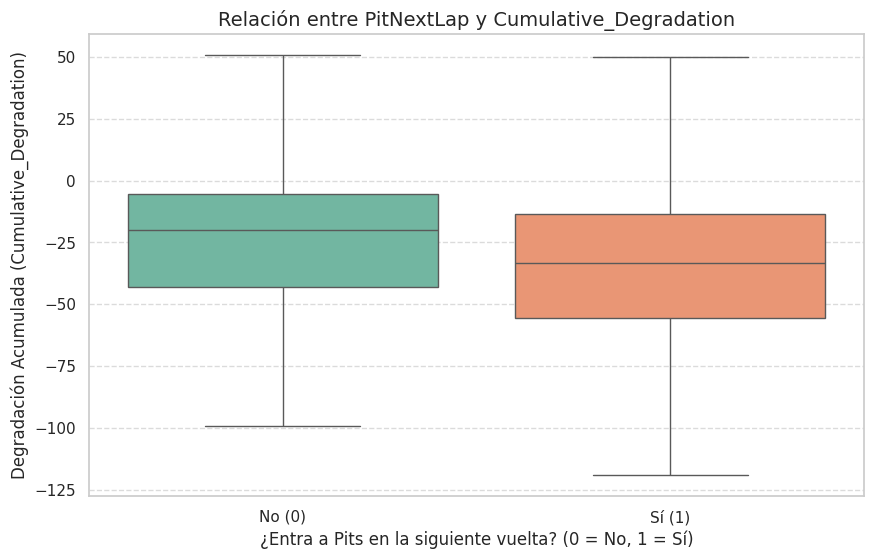

In [31]:
plt.figure(figsize=(10, 6))
# Usamos showfliers=False para ver mejor la distribución principal sin los valores atípicos extremos
sns.boxplot(data=df_1, x='PitNextLap', y='Cumulative_Degradation', hue='PitNextLap', palette='Set2', showfliers=False, legend=False)

plt.title('Relación entre PitNextLap y Cumulative_Degradation', fontsize=14)
plt.xlabel('¿Entra a Pits en la siguiente vuelta? (0 = No, 1 = Sí)', fontsize=12)
plt.ylabel('Degradación Acumulada (Cumulative_Degradation)', fontsize=12)
plt.xticks([0, 1], ['No (0)', 'Sí (1)'])
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

Es muy común confundir estas dos variables de "Cumulative_Degradation" y "tyreLife" porque intuitivamente pensamos que 'a mayor vida del neumático, mayor desgaste'. ¿por qué no están correlacionadas?:

TyreLife (Vida del Neumático): Es una medida de tiempo o uso absoluto. Básicamente es un contador que indica cuántas vueltas ha dado un neumático específico desde que se instaló en el coche. Aumenta linealmente de 1 en 1 en cada vuelta.

Cumulative_Degradation (Degradación Acumulada): Es una medida de rendimiento o desgaste físico. En lugar de simplemente contar vueltas, esta variable cuantifica la pérdida de adherencia o eficiencia del neumático.

¿Por qué no están fuertemente correlacionadas? La falta de una alta correlación lineal se debe a que la degradación no ocurre a un ritmo constante en cada vuelta. Depende de muchos factores:

El tipo de compuesto (Compound): Un neumático SOFT puede tener una degradación masiva en sus primeras 10 vueltas de TyreLife, mientras que un HARD puede mantener su rendimiento casi intacto en esas mismas 10 vueltas.
El estilo de conducción y la pista: Un piloto que empuja al límite desgastará la goma más rápido en menos vueltas.
Carga de combustible: Al inicio de la carrera, los coches pesan más, lo que acelera la degradación física del neumático, a pesar de que el TyreLife sea bajo.
En resumen: TyreLife te dice 'qué tan viejo es' el neumático en número de vueltas, mientras que Cumulative_Degradation te dice 'qué tan dañado está' en términos de rendimiento real. Un neumático puede tener muchas vueltas (TyreLife alto) pero poca degradación si se condujo de forma conservadora con un compuesto duro.

Relación entre Compound y Cumulative_Degradation

Analizamos cómo se distribuye la pérdida de rendimiento (degradación) dependiendo del tipo de neumático que se esté utilizando.

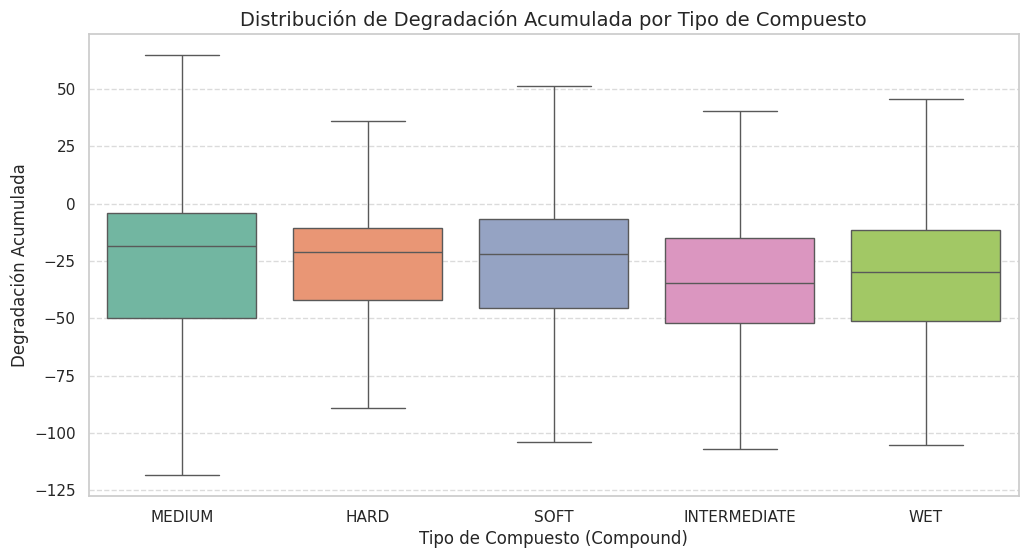

--- Estadísticas de Degradación por Compuesto ---


,mean,median,min,max,count
Compound,,,,,
INTERMEDIATE,-33.315040,-34.431,-245.783,175.508,17382
HARD,-32.933411,-21.241,-274.564,166.684,170507
WET,-30.736145,-29.858,-196.069,139.493,1354
SOFT,-25.167132,-22.063,-270.589,163.522,38744
MEDIUM,-19.548685,-18.541,-274.564,170.162,211126


In [34]:
# 1. Crear el boxplot sin outliers extremos para una mejor visualización
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_1, x='Compound', y='Cumulative_Degradation', hue='Compound', palette='Set2', showfliers=False, legend=False)

plt.title('Distribución de Degradación Acumulada por Tipo de Compuesto', fontsize=14)
plt.xlabel('Tipo de Compuesto (Compound)', fontsize=12)
plt.ylabel('Degradación Acumulada', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# 2. Calcular estadísticas clave de degradación por cada compuesto
degrad_stats = df_1.groupby('Compound')['Cumulative_Degradation'].agg(['mean', 'median', 'min', 'max', 'count']).sort_values(by='mean')

print('--- Estadísticas de Degradación por Compuesto ---')
display(degrad_stats)


### 📌 Conclusiones Clave: De Correlaciones a Degradación por Compuesto

**1. Principales Predictores de Parada (Correlaciones):**
* **Desgaste y Progreso:** `TyreLife` (0.27), `LapNumber` (0.27) y `RaceProgress` (0.19) son los indicadores positivos más fuertes. La decisión de entrar a pits es eminentemente estratégica y depende del tiempo en pista.
* **Rendimiento Físico:** `Cumulative_Degradation` (-0.17) indica que a mayor acumulación de pérdida de rendimiento (valores más negativos), más inminente es la llamada a boxes.
* **Variables sin impacto:** `Position` (0.02) y `LapTime` (-0.05) casi no influyen. Las paradas no se deciden por perder una posición o hacer una mala vuelta aislada, sino por la estrategia general.

**2. El Costo del Pit Stop (`LapTime_Delta`):**
Entrar a boxes produce la mayor dispersión e impacto en la diferencia de tiempos entre vueltas. Es el evento que más rompe la consistencia del ritmo de carrera, reflejándose en una alta varianza frente a mantenerse en pista.

**3. Estrategia y Tipo de Neumático (`Compound`):**
* **Elección Inicial:** La gran mayoría de los pilotos (~65%) prefieren arrancar la carrera con neumáticos **MEDIUM**.
* **El rol del compuesto HARD:** Aunque pocos inician con él, es el neumático con mayor volumen de paradas a pits. Esto sucede porque suele ser el neumático elegido para los *stints* medios y finales, buscando estirar la duración antes del recambio definitivo.

**4. Edad vs. Desgaste Real (`TyreLife` y `Cumulative_Degradation`):**
* La distribución de `TyreLife` muestra que la ventana crítica para ir a boxes se abre cerca de las **18-20 vueltas**, mientras que los autos que siguen en pista promedian apenas 11 vueltas.
* Quienes entran a pits muestran valores de degradación acumulada mucho más profundos (negativos). Esto resalta que **la decisión final cruza la edad de la goma con su pérdida de adherencia real**.
* Al cruzar Compuesto vs Degradación, vemos que el compuesto **HARD** llega a acumular niveles muy altos de degradación simplemente porque se le exige rodar por periodos mucho más prolongados que a un compuesto **SOFT** o **MEDIUM**.

## Guardado de DATOS

In [ ]:
# Guardar el dataset df_1 en la carpeta actual
output_filename = 'train_cleaned.csv'
df_1.to_csv(output_filename, index=False)
print(f"✅ Dataset guardado exitosamente como: {output_filename}")

✅ Dataset guardado exitosamente como: train_cleaned.csv


In [ ]:
import os

# Definir la ruta de destino en Google Drive
drive_output_path = '/content/drive/My Drive/ML_Notebooks/F1 Spit Stops/train_cleaned.csv'

# Guardar el DataFrame df_1 en Drive
try:
    df_1.to_csv(drive_output_path, index=False)

    # Verificar la grabación
    if os.path.exists(drive_output_path):
        print(f"✅ Éxito: El archivo se ha guardado físicamente en Drive.")
        print(f"Ruta: {drive_output_path}")
        print(f"Tamaño: {os.path.getsize(drive_output_path) / (1024*1024):.2f} MB")
    else:
        print("❌ Error: El archivo no se encuentra en la ruta de Drive tras el guardado.")
except Exception as e:
    print(f"❌ Error al guardar en Drive: {e}")
    print("Asegúrate de que la carpeta 'F1 Spit Stops' existe en tu Drive.")

✅ Éxito: El archivo se ha guardado físicamente en Drive.
Ruta: /content/drive/My Drive/ML_Notebooks/F1 Spit Stops/train_cleaned.csv
Tamaño: 48.40 MB
